In [360]:
# Import all datasets for sit to stand

import pandas as pd
from data_collector import get_sit_to_stand_paths, get_sit_to_stand_challenge_paths, get_water_task_paths, get_water_task_challenge_paths, get_step_count_paths, get_step_count_challenge_paths
import numpy as np

task = 'sit2stand'
if task == 'sit2stand':
    paths_standard = get_sit_to_stand_paths()
    paths_challenge = get_sit_to_stand_challenge_paths()
elif task == 'water':
    paths_standard = get_water_task_paths()
    paths_challenge = get_water_task_challenge_paths()
elif task == 'step_count':
    paths_standard = get_step_count_paths()
    paths_challenge = get_step_count_challenge_paths()

# Sort the paths by path.split('/')[-2]
paths_standard.sort(key=lambda x: x.split('/')[-2])
paths_challenge.sort(key=lambda x: x.split('/')[-2])

print("Standard paths:")
for path in paths_standard:
    print(path.split('/')[-2])

print("Challenge paths:")
for path in paths_challenge:
    print(path.split('/')[-2])


dfs_stand = [pd.read_csv(path) for path in paths_standard]
dfs_stand_challenge = [pd.read_csv(path) for path in paths_challenge]

if task=='step_count':
    # rename column from acceleration_m/s²_x to 'freeAcceleration_m/s²_x' for x y and z
    dfs_stand = [df.rename(columns={'acceleration_m/s²_x': 'freeAcceleration_m/s²_x', 'acceleration_m/s²_y': 'freeAcceleration_m/s²_y', 'acceleration_m/s²_z': 'freeAcceleration_m/s²_z'}) for df in dfs_stand]
    dfs_stand_challenge = [df.rename(columns={'acceleration_m/s²_x': 'freeAcceleration_m/s²_x', 'acceleration_m/s²_y': 'freeAcceleration_m/s²_y', 'acceleration_m/s²_z': 'freeAcceleration_m/s²_z'}) for df in dfs_stand_challenge]



for df in dfs_stand_challenge:
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )


df_standard = dfs_stand[0]
df_challenge = dfs_stand_challenge[0]

print(f"Using data from {paths_standard[0]} and {paths_challenge[0]}")

Data directory to look in: /Users/ashish/Desktop/DS4W/sensorhub-analysis/data
Sub directories for each Device ID found: ['f3eba7e5-dbda-4f4c-9fa8-8e8308b334f6', '5f680dfb-2510-4790-8f10-cb8724e7004c', '3c2d2423-8ac8-4a8c-95e2-aba5cc14abf8']
Data directory to look in: /Users/ashish/Desktop/DS4W/sensorhub-analysis/data
Sub directories for each Device ID found: ['f3eba7e5-dbda-4f4c-9fa8-8e8308b334f6', '5f680dfb-2510-4790-8f10-cb8724e7004c', '3c2d2423-8ac8-4a8c-95e2-aba5cc14abf8']
Standard paths:
2025-05-08T11_46_54Z-sit_to_stand
2025-05-08T12_46_28Z-sit_to_stand
2025-05-08T12_59_06Z-sit_to_stand
2025-05-12T06_56_53Z-sit_to_stand
2025-05-12T07_09_32Z-sit_to_stand
Challenge paths:
2025-05-08T11_54_27Z-sit_to_stand_challenge
2025-05-08T12_47_41Z-sit_to_stand_challenge
2025-05-08T13_00_24Z-sit_to_stand_challenge
2025-05-12T06_58_28Z-sit_to_stand_challenge
2025-05-12T07_10_26Z-sit_to_stand_challenge
Using data from /Users/ashish/Desktop/DS4W/sensorhub-analysis/data/3c2d2423-8ac8-4a8c-95e2-aba5

In [361]:
def preprocess_data(df):
    from scipy import signal, integrate

    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000

    # Calculate magnitude of acceleration 
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )

    # Apply detrending to each axis
    df['acc_detrended_x'] = signal.detrend(df['freeAcceleration_m/s²_x'], type='linear')
    df['acc_detrended_y'] = signal.detrend(df['freeAcceleration_m/s²_y'], type='linear')
    df['acc_detrended_z'] = signal.detrend(df['freeAcceleration_m/s²_z'], type='linear')

    # Calculate detrended magnitude of acceleration
    df['acceleration_magnitude_detrended'] = np.sqrt(df['acc_detrended_x']**2 + df['acc_detrended_y']**2 + df['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df['velocity_z'] = integrate.cumulative_trapezoid(df['acc_detrended_z'], df['time_s'], initial=0)
    df['velocity_x'] = integrate.cumulative_trapezoid(df['acc_detrended_x'], df['time_s'], initial=0)
    df['velocity_y'] = integrate.cumulative_trapezoid(df['acc_detrended_y'], df['time_s'], initial=0)

    # Calculate magnitude of velocity
    df['velocity_magnitude'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2 + df['velocity_z']**2)

    # Calculate position with detrending
    df['position_z'] = integrate.cumulative_trapezoid(df['velocity_z'], df['time_s'], initial=0)
    df['position_x'] = integrate.cumulative_trapezoid(df['velocity_x'], df['time_s'], initial=0)
    df['position_y'] = integrate.cumulative_trapezoid(df['velocity_y'], df['time_s'], initial=0)

    return df

dfs_stand = [preprocess_data(df) for df in dfs_stand]
dfs_stand_challenge = [preprocess_data(df) for df in dfs_stand_challenge]
    
    

    



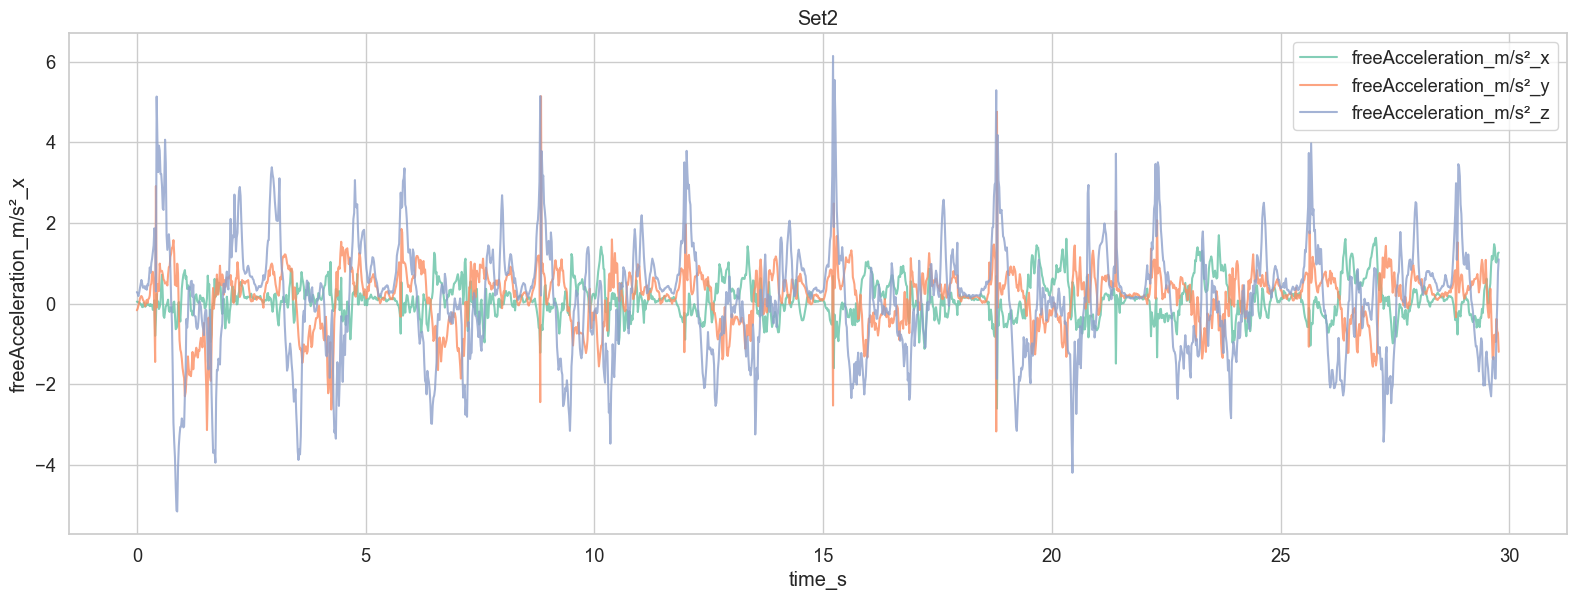

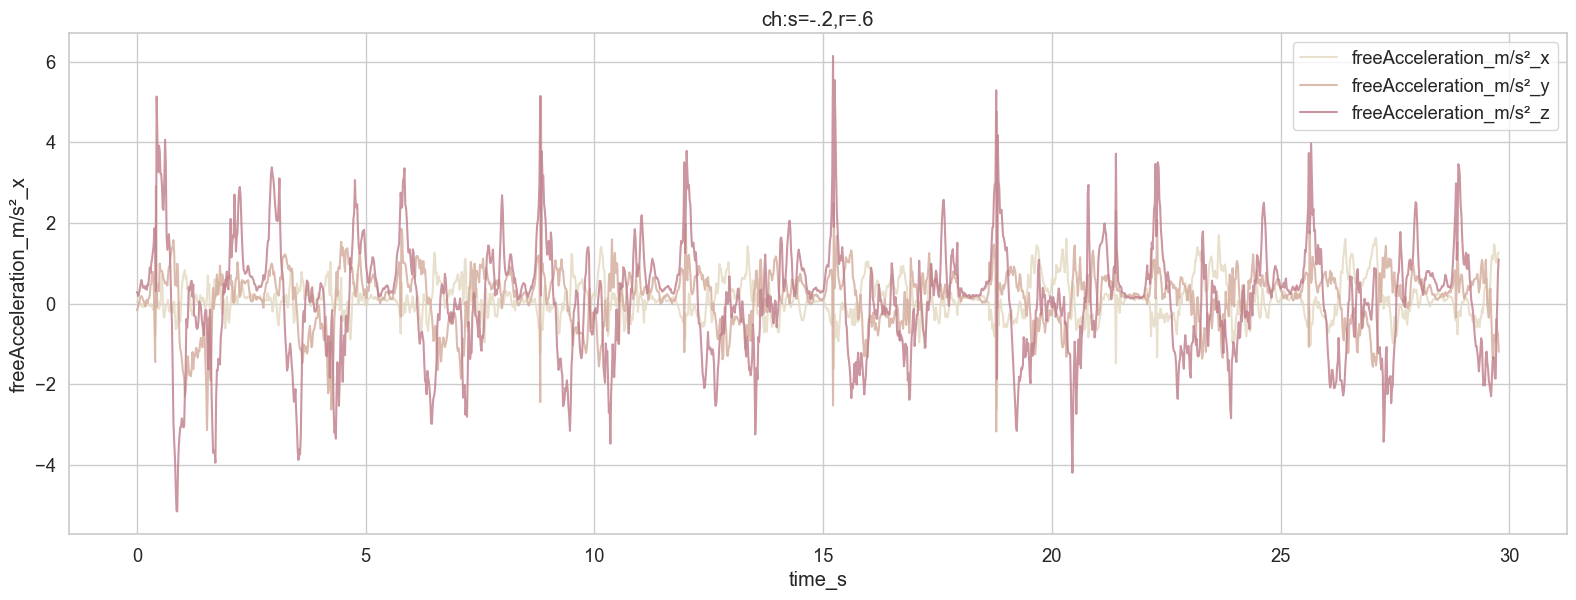

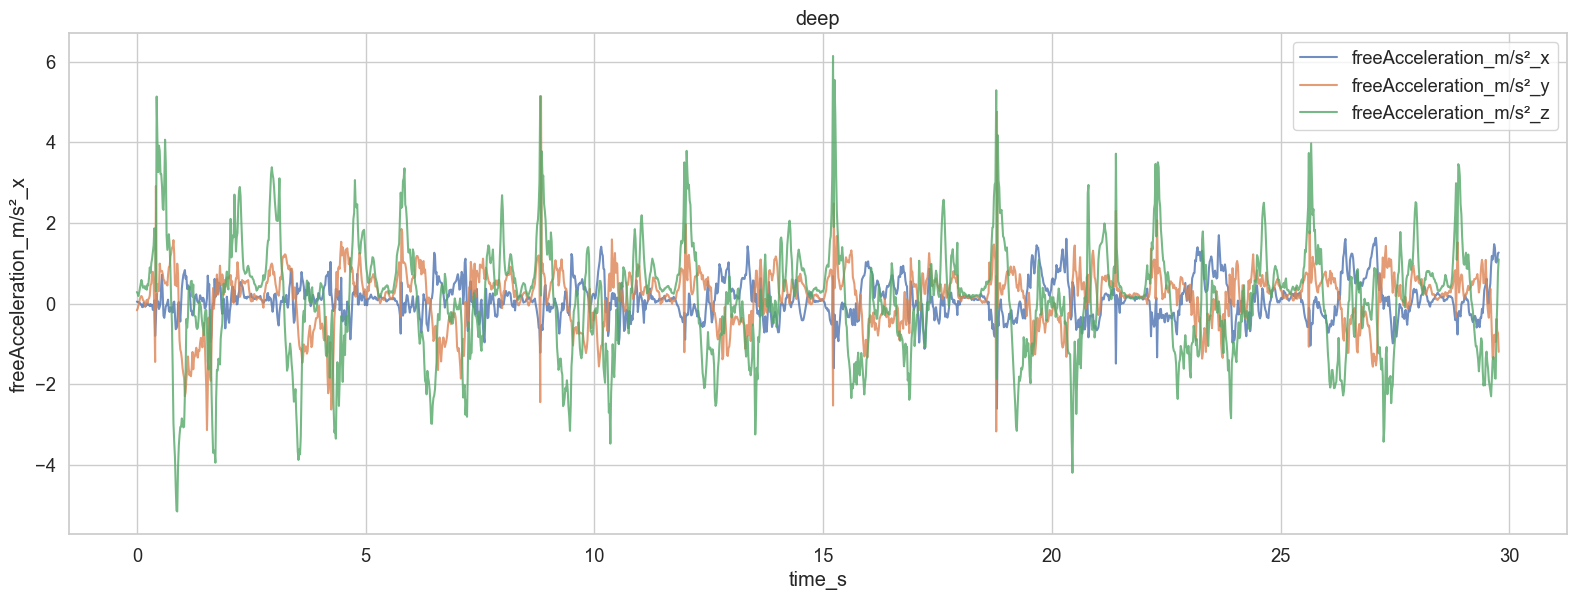

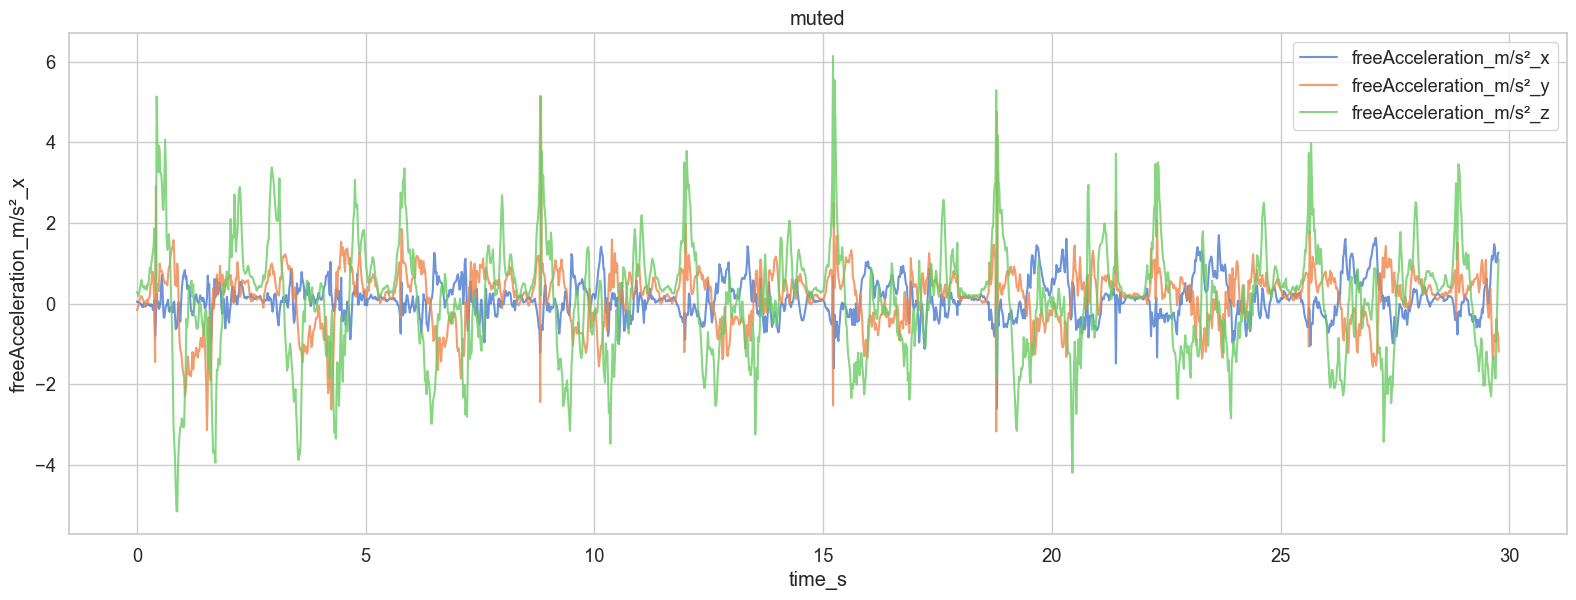

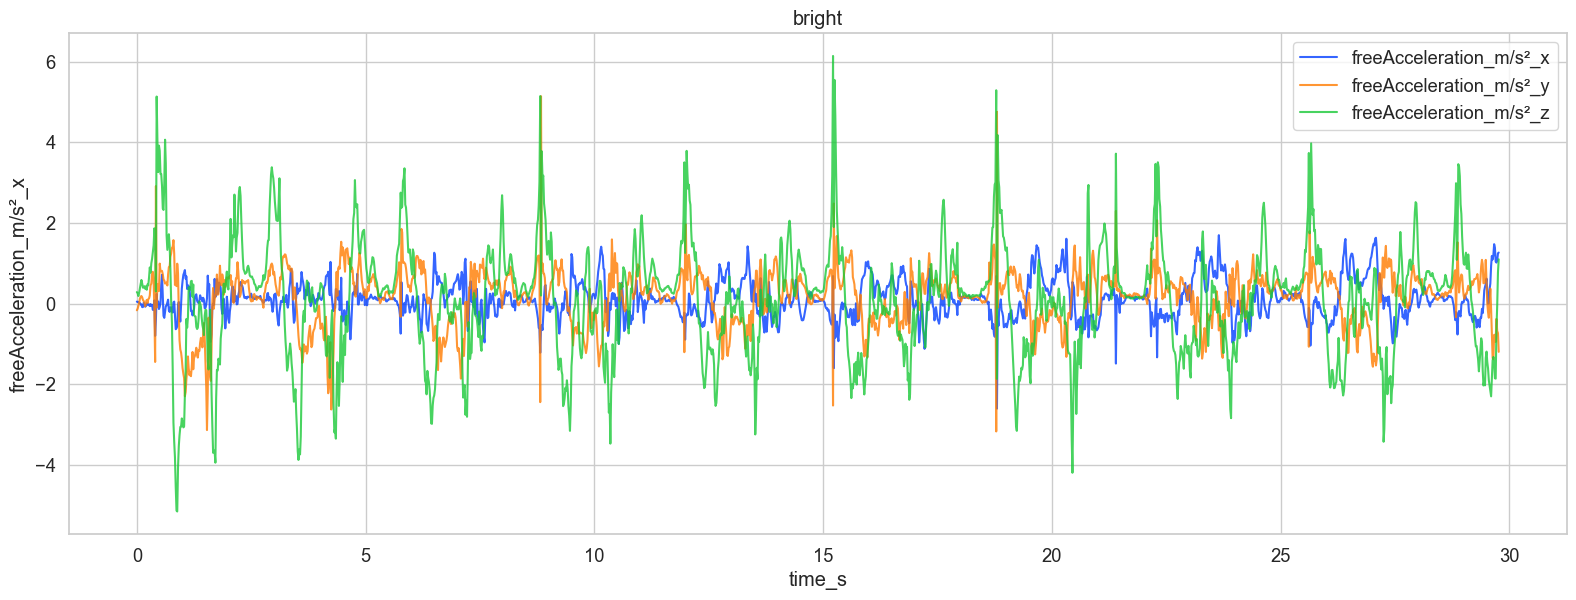

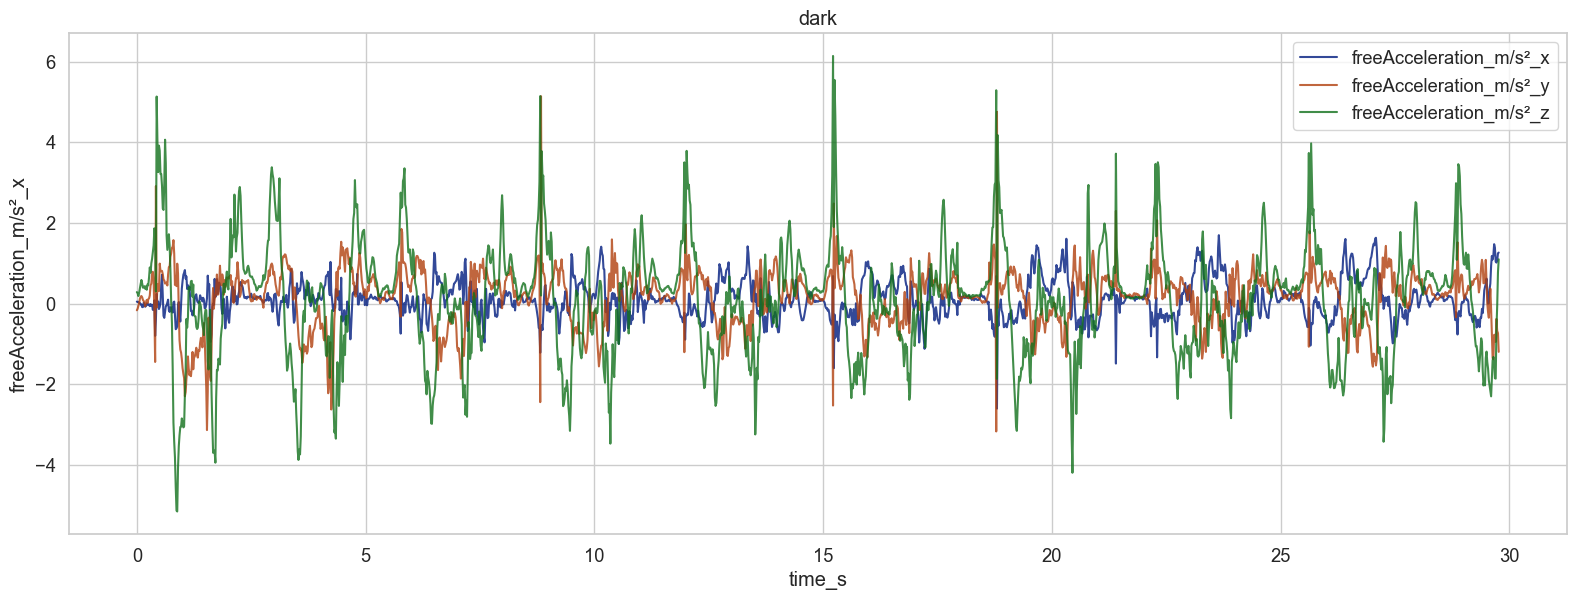

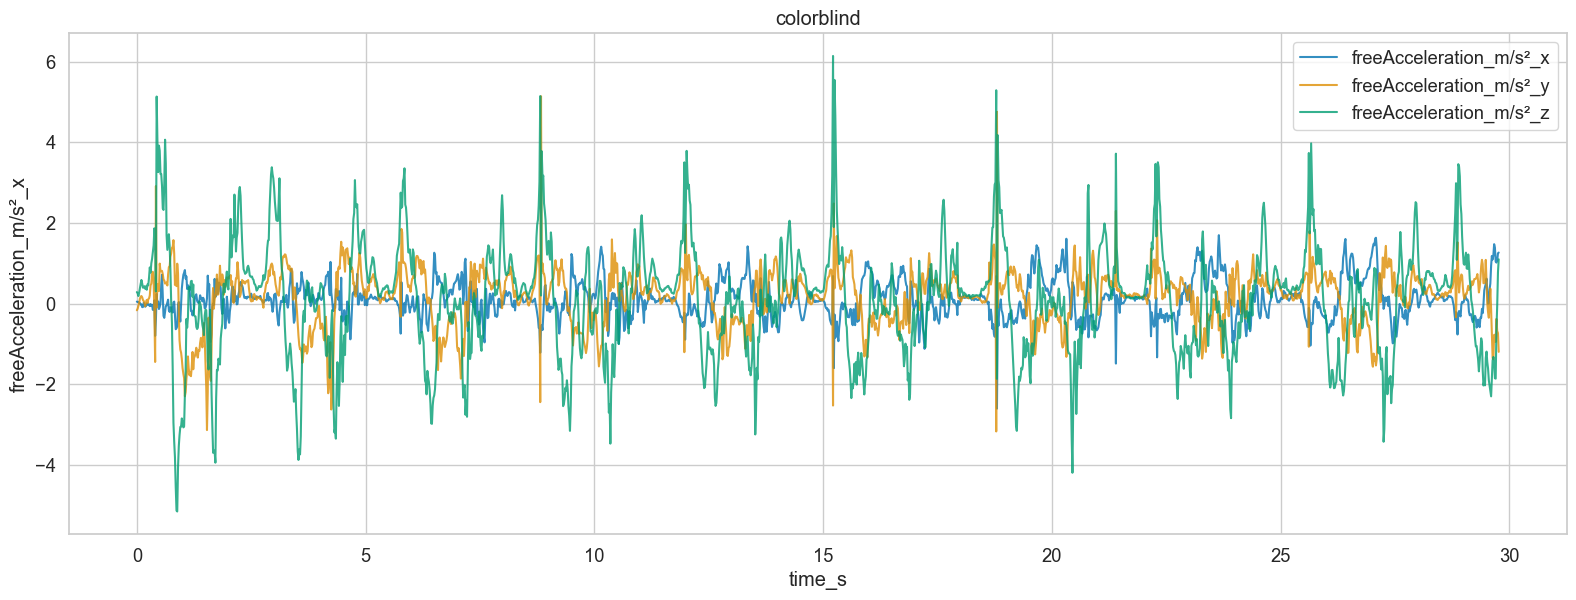

In [362]:
def plot_column_sns(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style('whitegrid')

    color_palattes = ["Set2", "ch:s=-.2,r=.6", 'deep', 'muted', 'bright', 'dark', 'colorblind']
    for color in color_palattes:
        sns.set_palette(color)
        plt.figure(figsize=(16, 6))
        for i, column_name in enumerate(column_names):
            # plot the column_name vs time_s and include appropriate legend
            sns.lineplot(
                data=df,
                x='time_s',
                y=column_name,
                alpha=0.8,
                label=column_name
            )
            plt.tight_layout()
        plt.title(color)
plot_column_sns(dfs_stand[0], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'])

In [363]:
def plot_column(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    # colors = sns.color_palette("prism", len(column_names))

    if title is None:
        title = ' | '.join(column_names)

    colorblind_safe_colors = [
    # "#000000",  # black
    # "#E69F00",  # orange
    "#56B4E9",  # sky blue
    # "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]


    # plot the column_name vs time_s
    plt.figure(figsize=(16, 6))
    for i, column_name in enumerate(column_names):
        plt.plot(df['time_s'], df[column_name], label=column_name, color=colorblind_safe_colors[i])
        plt.xlabel('Time (s)')
        plt.ylabel(column_name)
        plt.legend()
    plt.title(title)

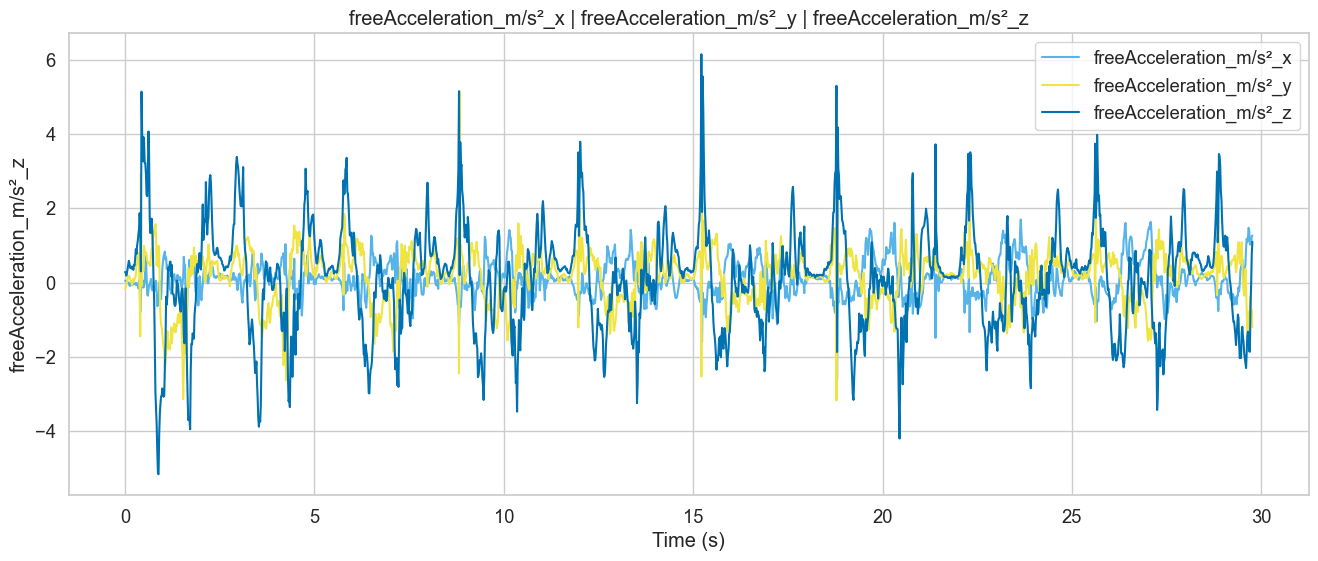

In [364]:
plot_column(dfs_stand[0], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'])

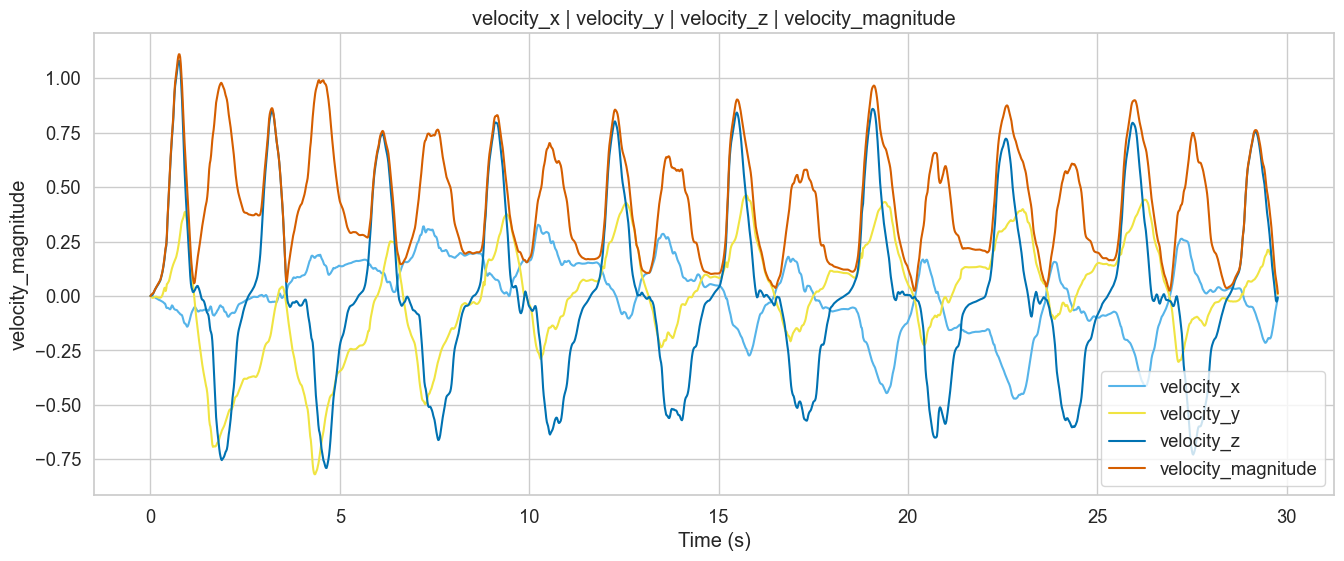

In [365]:
plot_column(dfs_stand[0], ['velocity_x', 'velocity_y', 'velocity_z', 'velocity_magnitude'])

In [366]:
# Calculate the troughs and peaks of the velocity_z
from scipy.signal import find_peaks

def calculate_peaks_and_troughs(df, column_name):
    peaks, _ = find_peaks(df[column_name], distance=20, prominence=0.5)
    troughs, _ = find_peaks(-df[column_name], distance=20, prominence=0.5)
    return peaks, troughs

standard_peaks, standard_troughs = calculate_peaks_and_troughs(dfs_stand[0], 'velocity_z')
challenge_peaks, challenge_troughs = calculate_peaks_and_troughs(dfs_stand_challenge[0], 'velocity_z')

In [367]:
def calculate_and_plot_peaks_and_troughs(df, column_name):
    import matplotlib.pyplot as plt
    peaks, troughs = calculate_peaks_and_troughs(df, column_name)
    plt.figure(figsize=(26, 8))
    plt.plot(df['time_s'], df[column_name])
    plt.scatter(df['time_s'][peaks], df[column_name][peaks], color='red', label='Peaks', marker='x')
    plt.scatter(df['time_s'][troughs], df[column_name][troughs], color='blue', label='Troughs', marker='x')
    plt.legend()
    plt.title(f'{column_name} Peaks and Troughs')



<Figure size 3000x800 with 0 Axes>

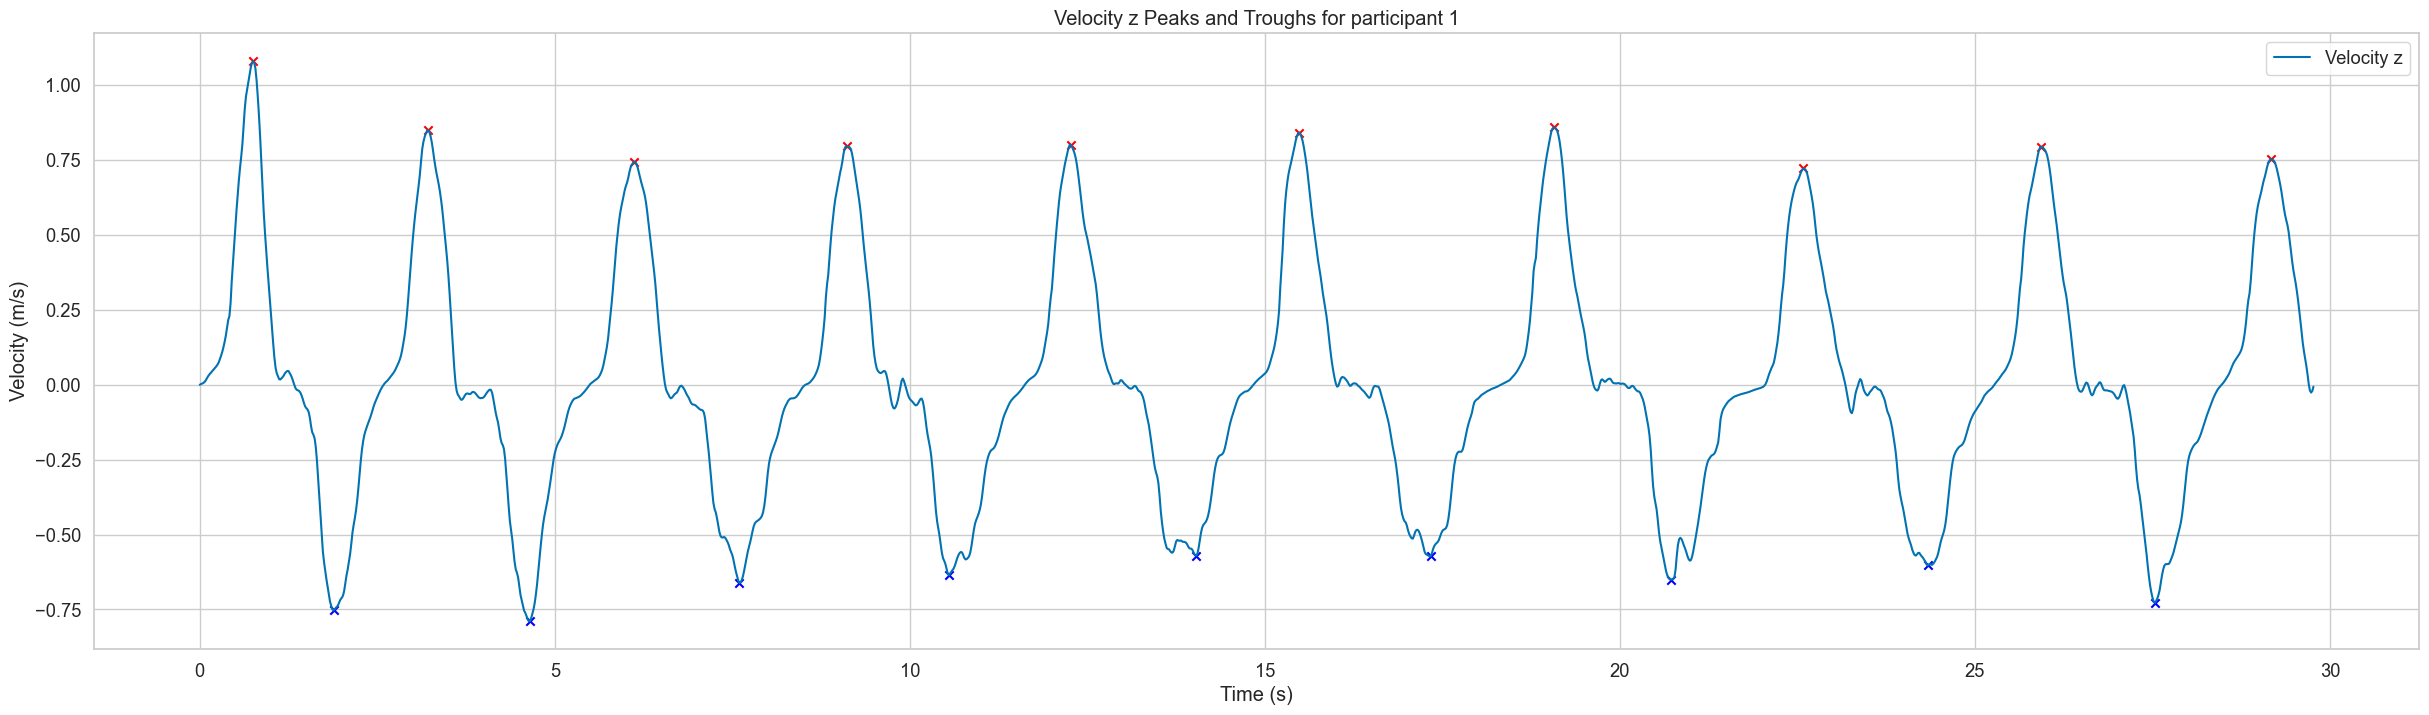

Participant 1 has 2 peaks and 3 troughs along x axis
Participant 1 has 8 peaks and 9 troughs along y axis
Participant 1 has 10 peaks and 9 troughs along z axis


<Figure size 3000x800 with 0 Axes>

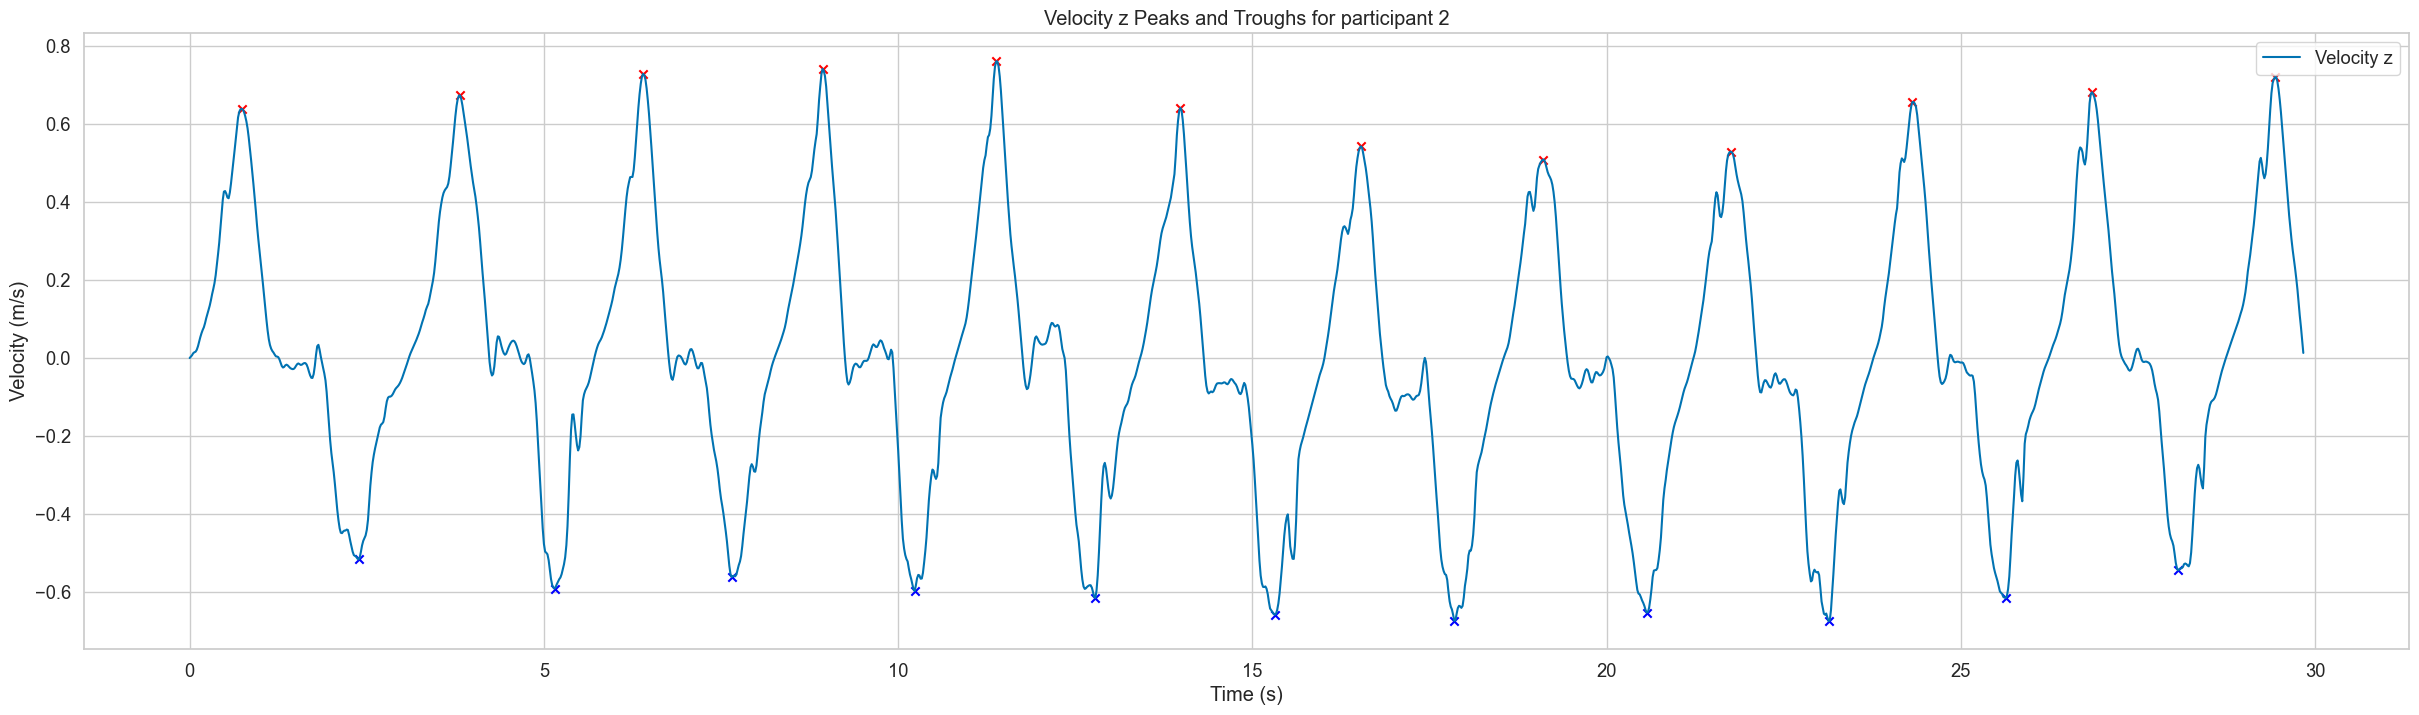

Participant 2 has 0 peaks and 0 troughs along x axis
Participant 2 has 10 peaks and 11 troughs along y axis
Participant 2 has 12 peaks and 11 troughs along z axis


<Figure size 3000x800 with 0 Axes>

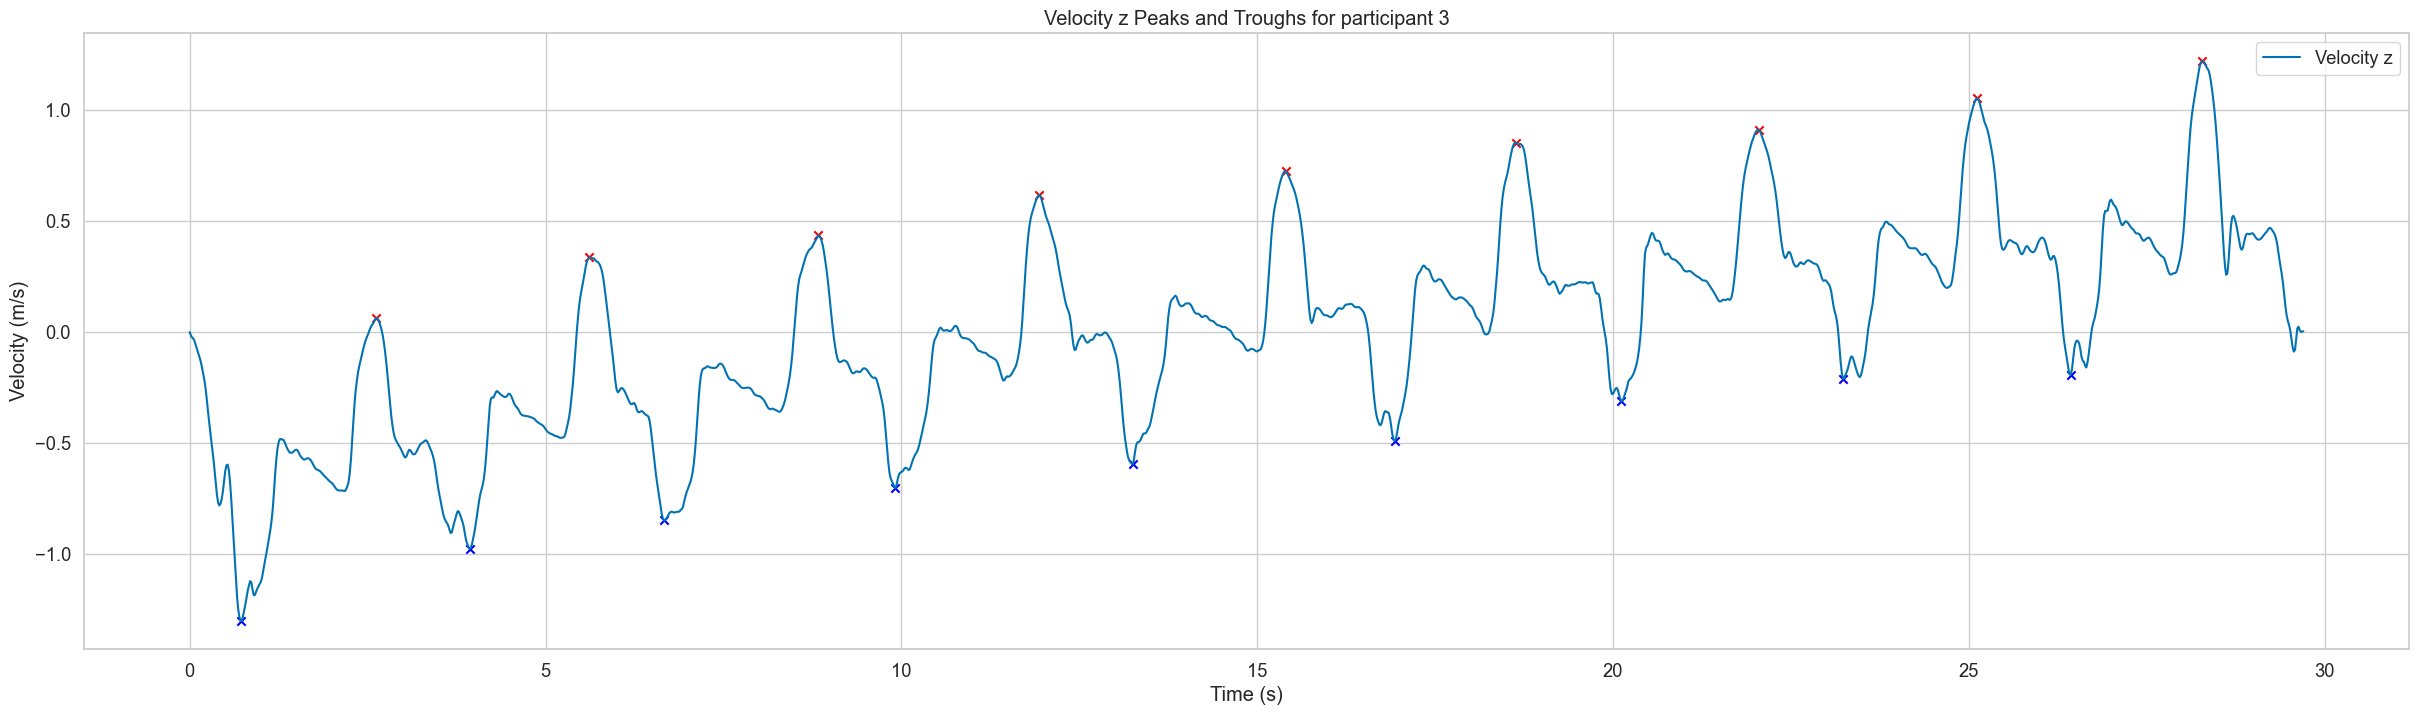

Participant 3 has 1 peaks and 1 troughs along x axis
Participant 3 has 8 peaks and 8 troughs along y axis
Participant 3 has 9 peaks and 9 troughs along z axis


<Figure size 3000x800 with 0 Axes>

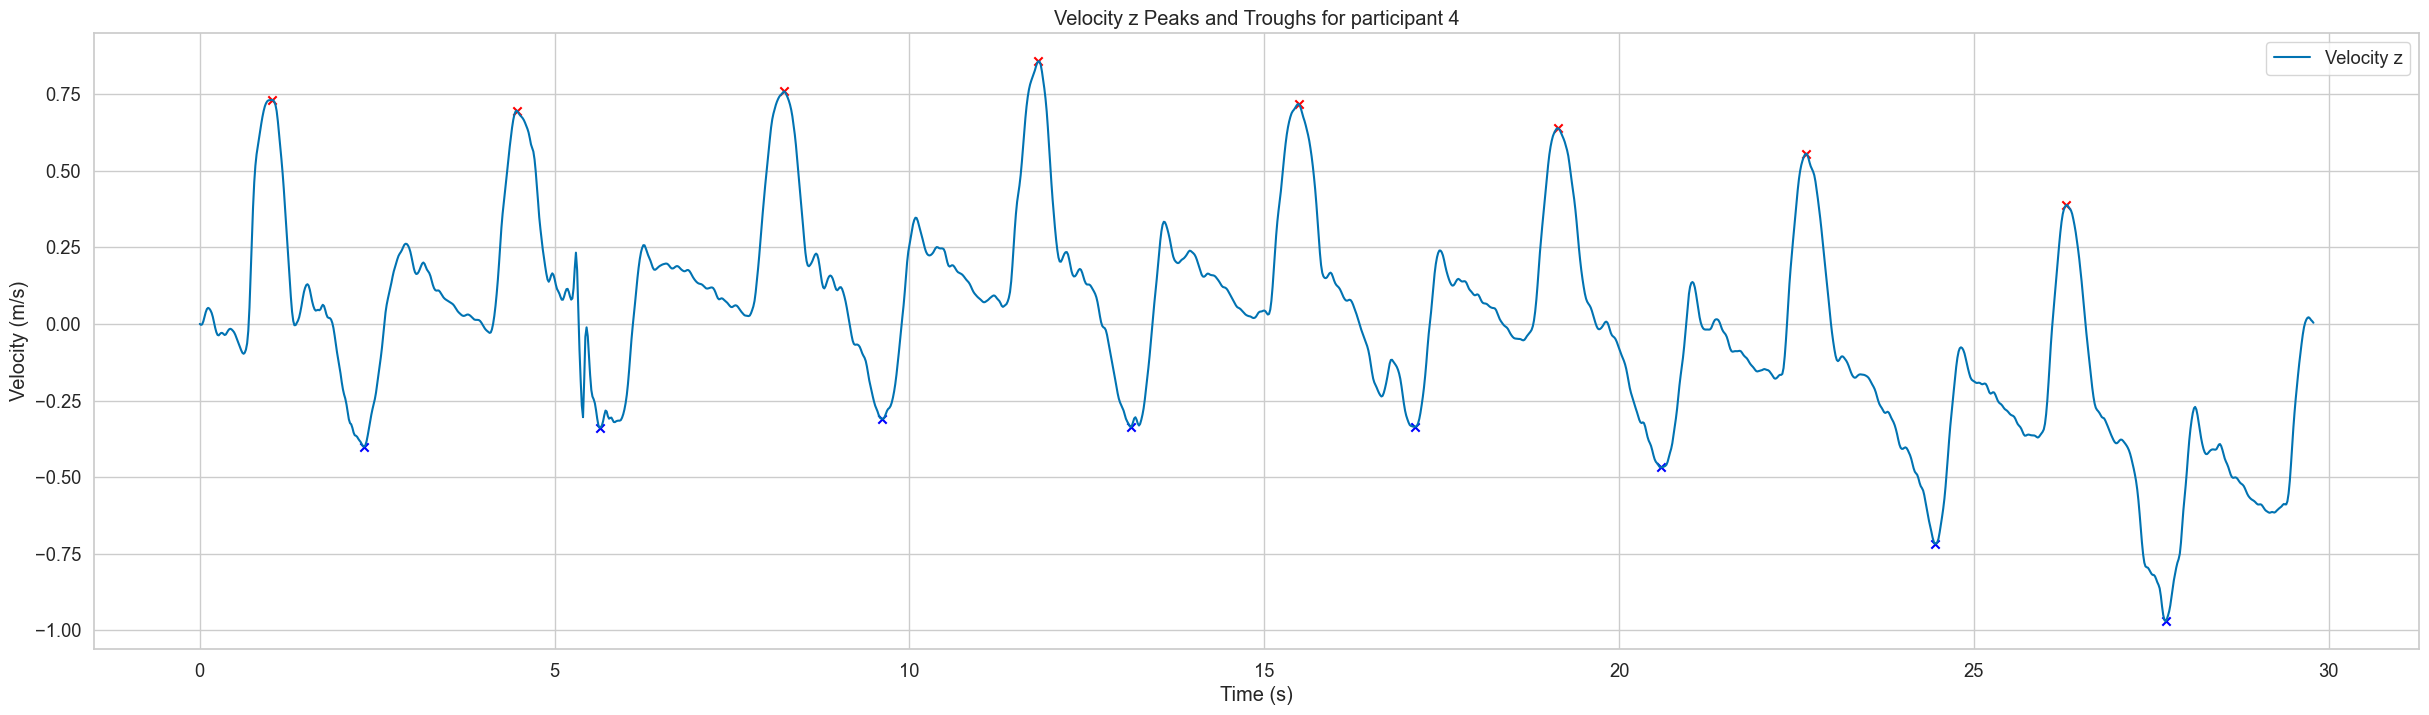

Participant 4 has 7 peaks and 7 troughs along x axis
Participant 4 has 1 peaks and 0 troughs along y axis
Participant 4 has 8 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

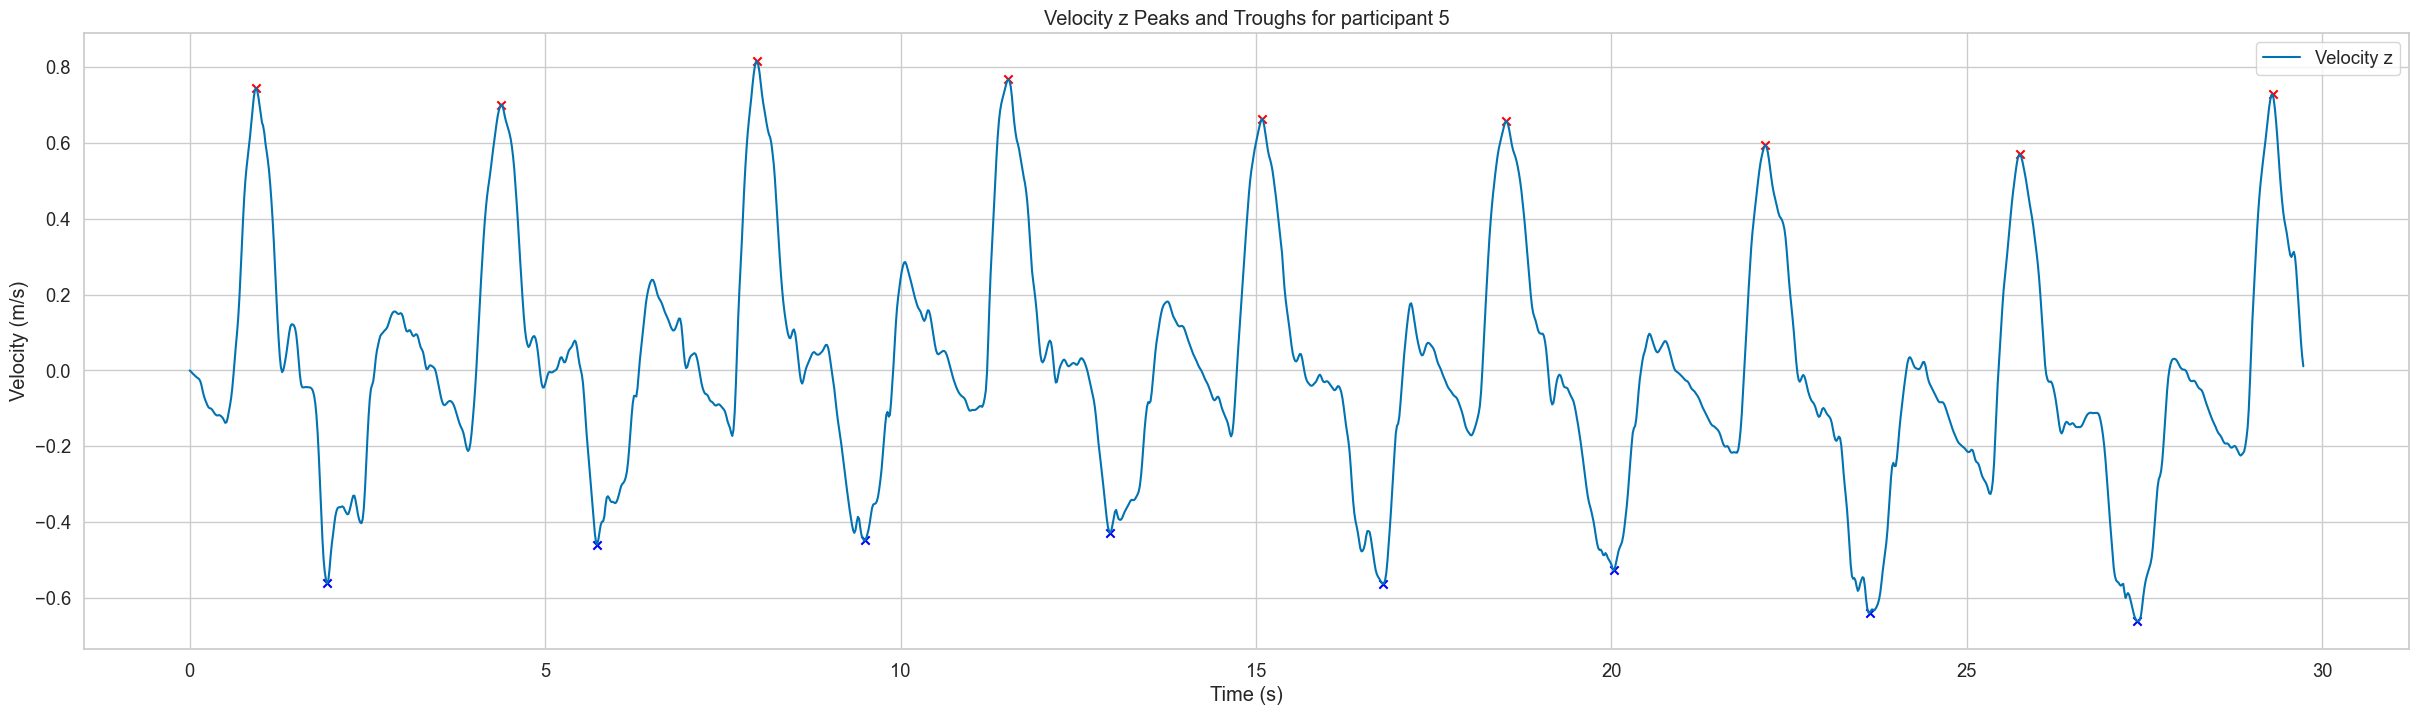

Participant 5 has 7 peaks and 8 troughs along x axis
Participant 5 has 0 peaks and 0 troughs along y axis
Participant 5 has 9 peaks and 8 troughs along z axis


In [368]:
# For each participant in dfs_stand, calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
for i, dataframe in enumerate(dfs_stand):
    import matplotlib.pyplot as plt
    # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y

    plot_others = False
    # Make the plots more beautiful and academic
    plt.figure(figsize=(30, 8))


    plt.figure(figsize=(30, 8))
    # Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively
    standard_peaks_x, standard_troughs_x = calculate_peaks_and_troughs(dataframe, 'velocity_x')
    standard_peaks_y, standard_troughs_y = calculate_peaks_and_troughs(dataframe, 'velocity_y')
    standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(dataframe, 'velocity_z')

    plt.plot(dataframe['time_s'], dataframe['velocity_z'], label='Velocity z')
    plt.scatter(dataframe['time_s'][standard_peaks_z], dataframe['velocity_z'][standard_peaks_z], color='red', marker='x')
    plt.scatter(dataframe['time_s'][standard_troughs_z], dataframe['velocity_z'][standard_troughs_z], color='blue', marker='x')

    if plot_others:
        # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively

        plt.plot(dataframe['time_s'], dataframe['velocity_y'], label='Velocity y')
        plt.scatter(dataframe['time_s'][standard_peaks_y], dataframe['velocity_y'][standard_peaks_y], color='red', marker='x')
        plt.scatter(dataframe['time_s'][standard_troughs_y], dataframe['velocity_y'][standard_troughs_y], color='blue', marker='x')

        plt.plot(dataframe['time_s'], dataframe['velocity_x'], label='Velocity x')
        plt.scatter(dataframe['time_s'][standard_peaks_x], dataframe['velocity_x'][standard_peaks_x], color='red', marker='x')
        plt.scatter(dataframe['time_s'][standard_troughs_x], dataframe['velocity_x'][standard_troughs_x], color='blue', marker='x')

        plt.plot(dataframe['time_s'], dataframe['velocity_magnitude'], label='Velocity magnitude', color='black')

    plt.legend()
    plt.title(f'Velocity z Peaks and Troughs for participant {i+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.show()

    print(f"Participant {i+1} has {len(standard_peaks_x)} peaks and {len(standard_troughs_x)} troughs along x axis")
    print(f"Participant {i+1} has {len(standard_peaks_y)} peaks and {len(standard_troughs_y)} troughs along y axis")
    print(f'Participant {i+1} has {len(standard_peaks_z)} peaks and {len(standard_troughs_z)} troughs along z axis')
    
    



In [369]:
dfs_stand[0]

,timestamp_ms,timestamp_μs,freeAcceleration_m/s²_x,freeAcceleration_m/s²_y,freeAcceleration_m/s²_z,time_s,acceleration_magnitude,acc_detrended_x,acc_detrended_y,acc_detrended_z,acceleration_magnitude_detrended,velocity_z,velocity_x,velocity_y,velocity_magnitude,position_z,position_x,position_y
0,1746704814859,209719360,0.047203,-0.167005,0.283479,0.000,0.332384,-0.013365,-0.239460,0.163328,0.290165,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1746704814876,209736027,0.038527,-0.128904,0.256366,0.017,0.289524,-0.022086,-0.201454,0.136254,0.244206,0.002546,-0.000301,-0.003748,0.004541,0.000022,-0.000003,-0.000032
2,1746704814892,209752694,0.040116,-0.065615,0.185970,0.033,0.201245,-0.020543,-0.138260,0.065899,0.154533,0.004164,-0.000642,-0.006465,0.007717,0.000075,-0.000010,-0.000114
3,1746704814909,209769361,0.015788,0.011174,0.267086,0.050,0.267786,-0.044915,-0.061567,0.147054,0.165628,0.005974,-0.001199,-0.008164,0.010187,0.000161,-0.000026,-0.000238
4,1746704814926,209786028,0.013383,0.116792,0.386025,0.067,0.403528,-0.047365,0.043955,0.266033,0.273768,0.009485,-0.001983,-0.008314,0.012768,0.000293,-0.000053,-0.000378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1782,1746704844560,239419954,1.038621,-0.952962,-1.862821,29.701,2.336016,0.897970,-1.195588,-1.912185,2.427392,0.001922,-0.072213,0.069659,0.100353,0.016065,0.023060,-0.072925
1783,1746704844576,239436621,1.016820,-0.380841,-0.648541,29.717,1.264740,0.876123,-0.623562,-0.697866,1.281967,-0.018958,-0.058020,0.055105,0.082234,0.015928,0.022018,-0.071927
1784,1746704844593,239453288,1.064942,-0.680544,-0.057891,29.734,1.265145,0.924200,-0.923361,-0.107176,1.310812,-0.025801,-0.042717,0.041957,0.065198,0.015548,0.021162,-0.071102
1785,1746704844610,239469955,1.247072,-0.734097,0.777641,29.751,1.642807,1.106286,-0.977010,0.728396,1.645897,-0.020521,-0.025458,0.025803,0.041654,0.015154,0.020582,-0.070526


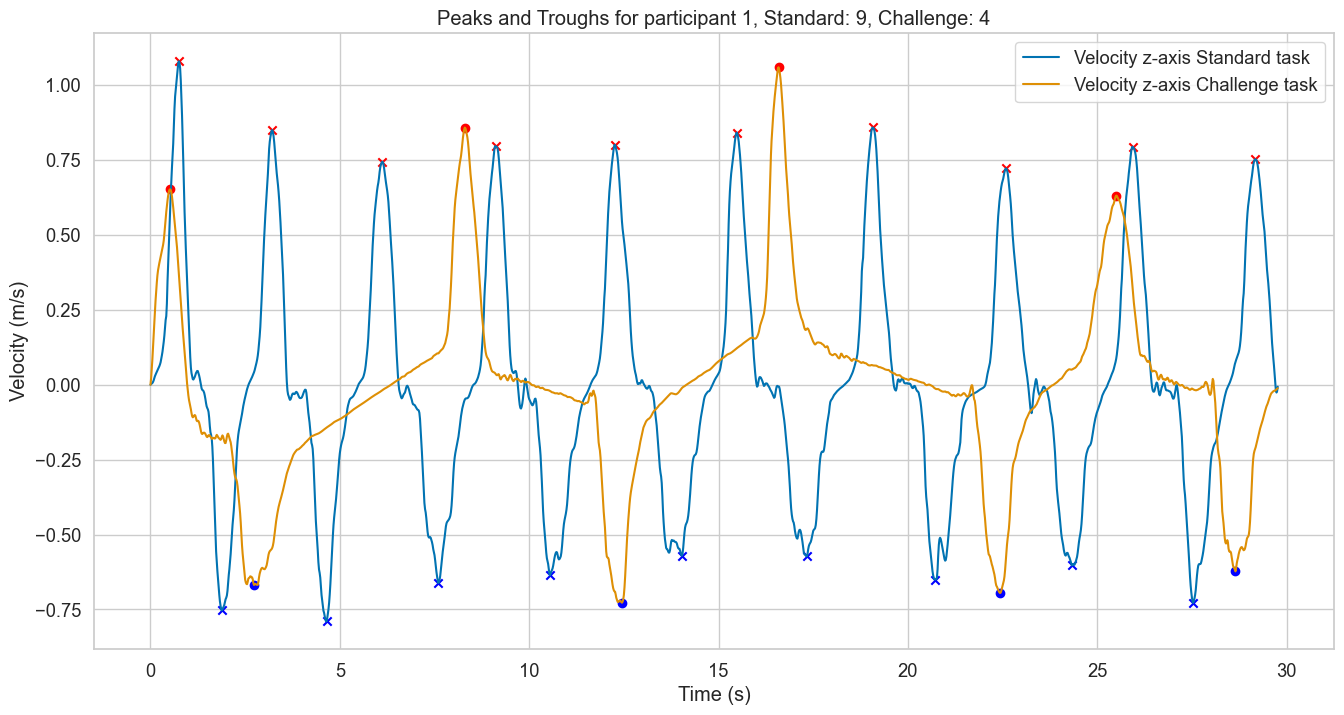

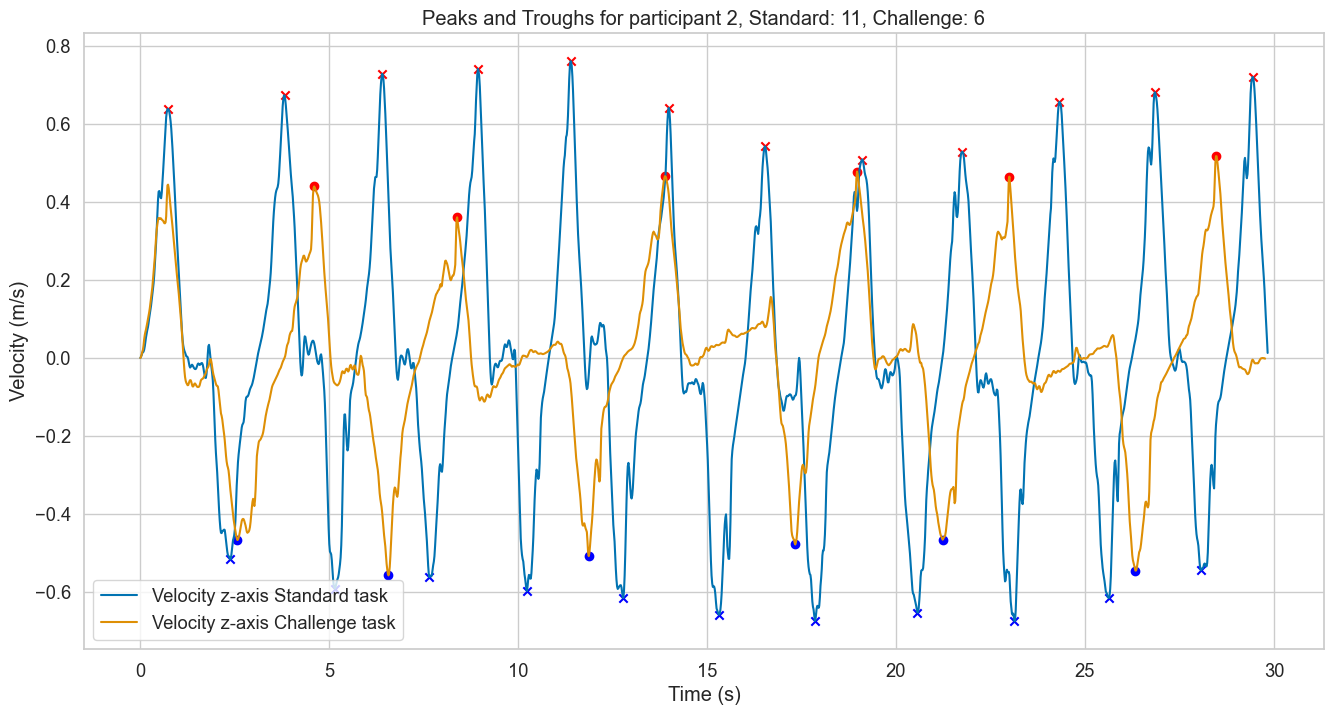

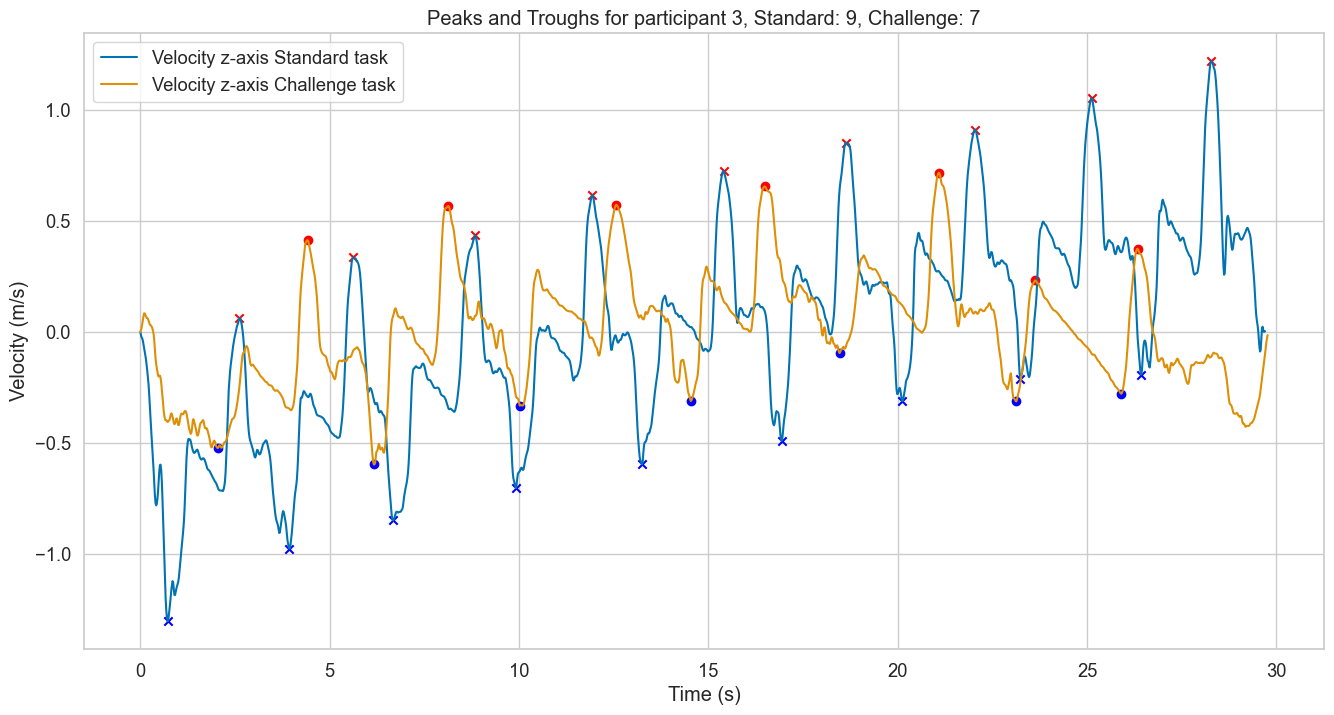

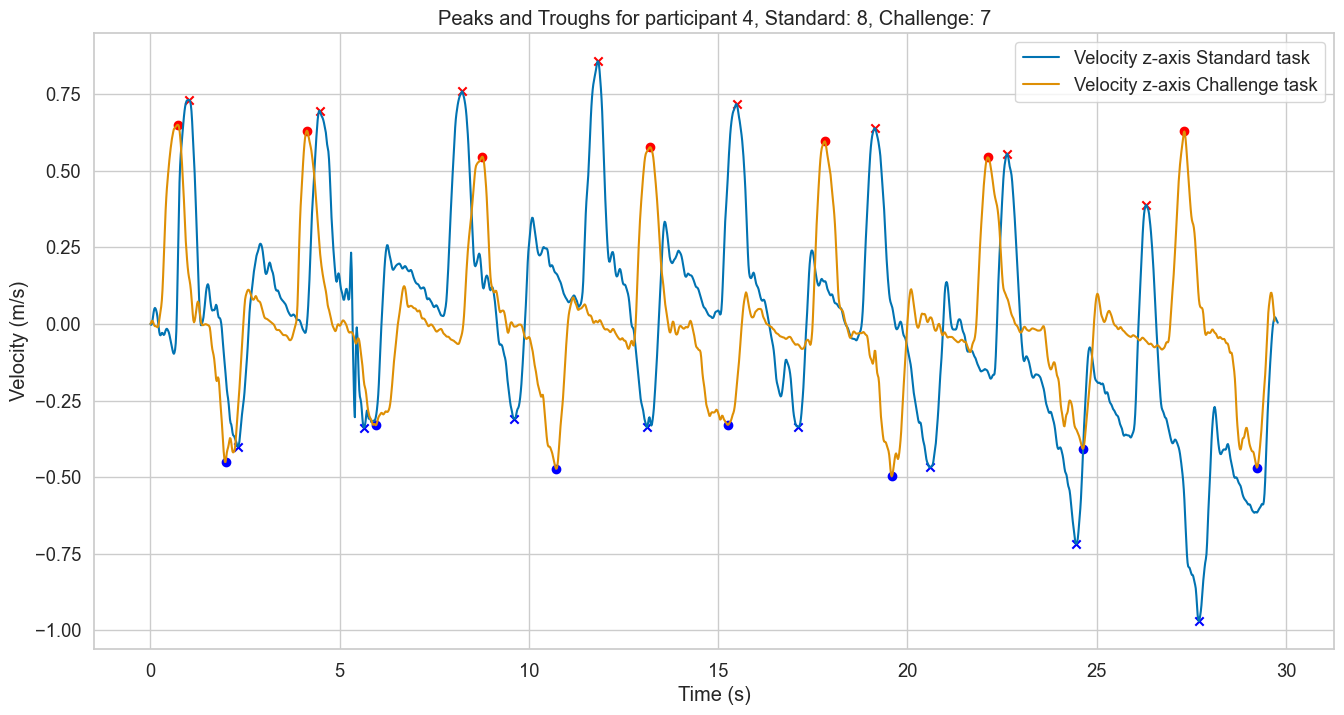

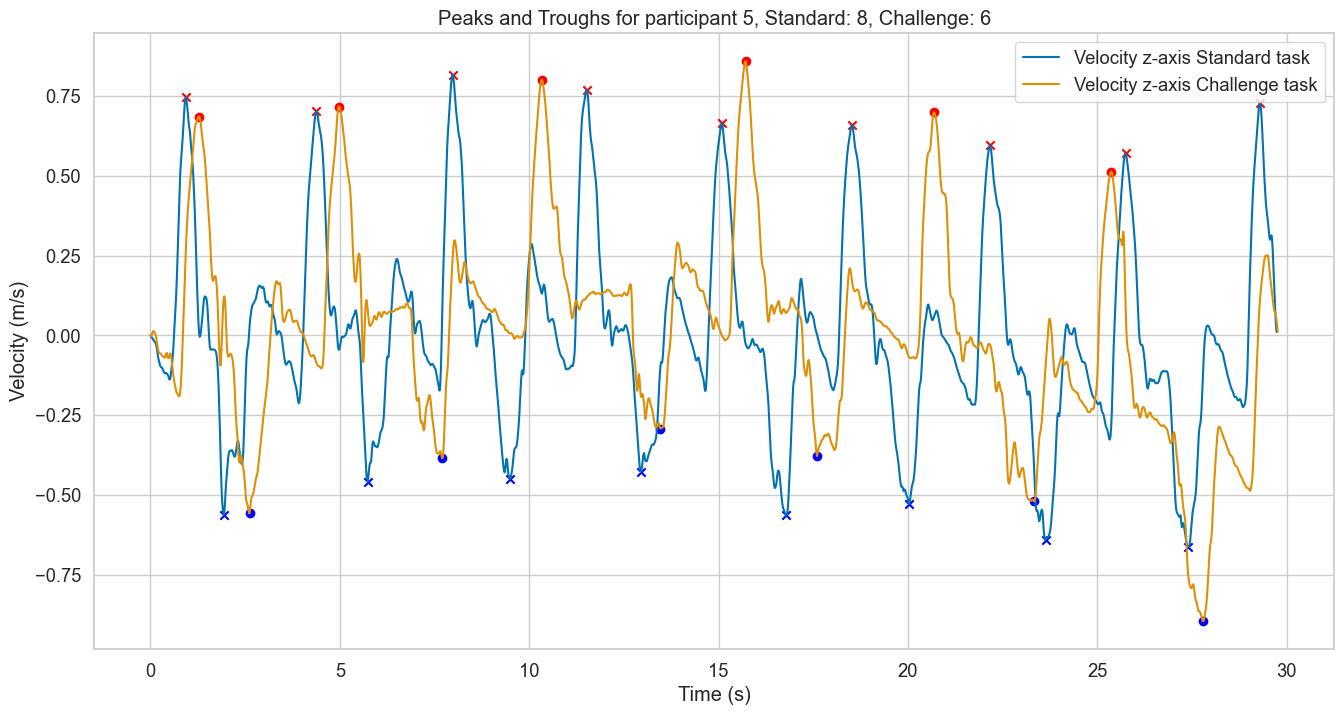

In [370]:
# For each participant in dfs_stand, calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
counts_standard = []
counts_challenge = []

for i in range(len(dfs_stand)):
    import matplotlib.pyplot as plt
    # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y

    dataframe_standard = dfs_stand[i]
    dataframe_challenge = dfs_stand_challenge[i]


    plt.figure(figsize=(16, 8))
    # Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively
    standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(dataframe_standard, 'velocity_z')
    challenge_peaks_z, challenge_troughs_z = calculate_peaks_and_troughs(dataframe_challenge, 'velocity_z')

    count_standard = (len(standard_peaks_z) + len(standard_troughs_z))//2
    count_challenge = (len(challenge_peaks_z) + len(challenge_troughs_z))//2

    counts_standard.append(count_standard)
    counts_challenge.append(count_challenge)

    plt.plot(dataframe_standard['time_s'], dataframe_standard['velocity_z'], label='Velocity z-axis Standard task')
    plt.scatter(dataframe_standard['time_s'][standard_peaks_z], dataframe_standard['velocity_z'][standard_peaks_z], color='red', marker='x')
    plt.scatter(dataframe_standard['time_s'][standard_troughs_z], dataframe_standard['velocity_z'][standard_troughs_z], color='blue', marker='x')

    plt.plot(dataframe_challenge['time_s'], dataframe_challenge['velocity_z'], label='Velocity z-axis Challenge task')
    plt.scatter(dataframe_challenge['time_s'][challenge_peaks_z], dataframe_challenge['velocity_z'][challenge_peaks_z], color='red', marker='o')
    plt.scatter(dataframe_challenge['time_s'][challenge_troughs_z], dataframe_challenge['velocity_z'][challenge_troughs_z], color='blue', marker='o')

    debug = False
    if debug:
        # Plot a straight line with x=0 at every trough of standard task
        for trough in standard_troughs_z:
            plt.axvline(x=dataframe_standard['time_s'][trough], color='black', linestyle='--')

        for trough in challenge_troughs_z:
            plt.axvline(x=dataframe_challenge['time_s'][trough], color='green', linestyle='--')
    

    plt.legend()
    plt.title(f'Peaks and Troughs for participant {i+1}, Standard: {count_standard}, Challenge: {count_challenge}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.show()
    
    




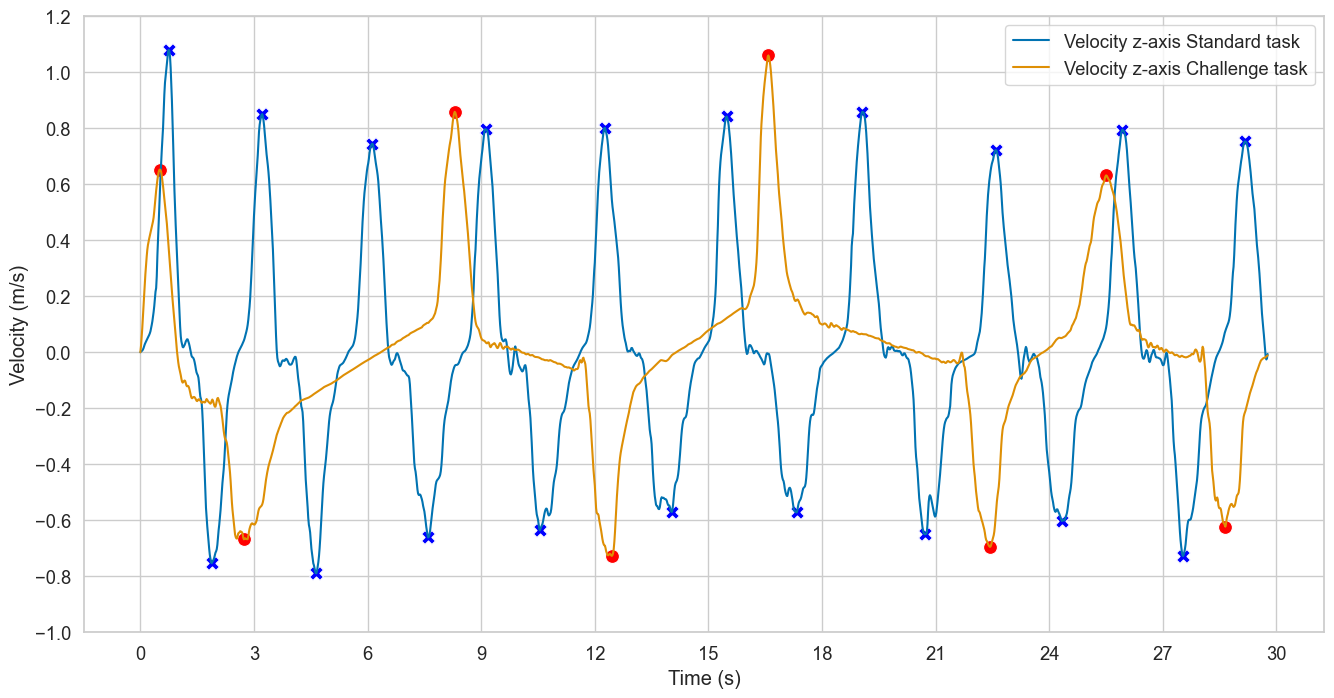

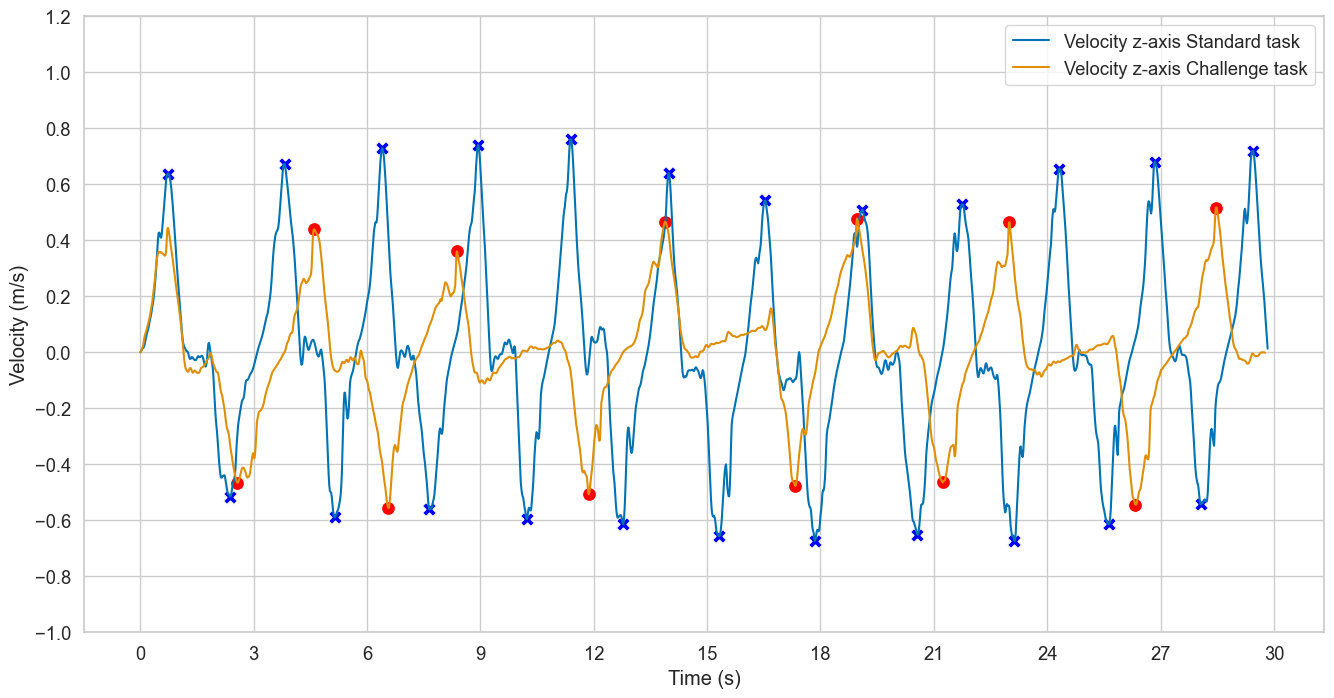

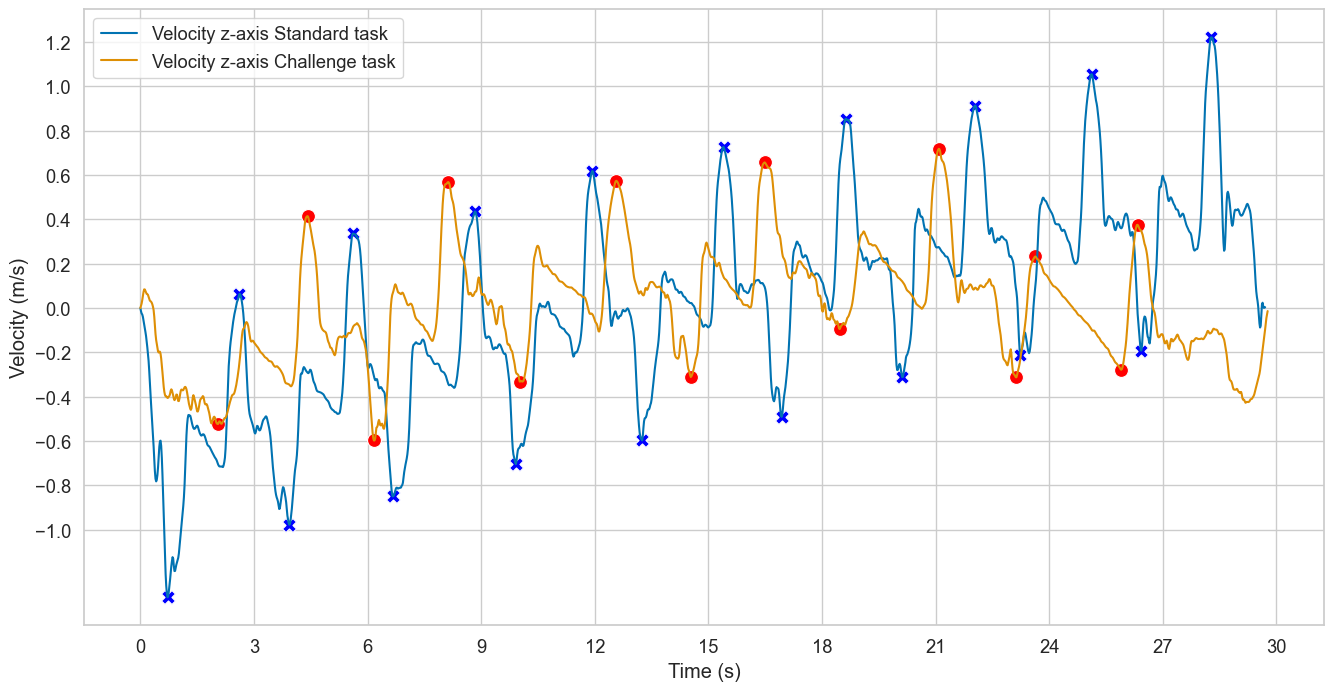

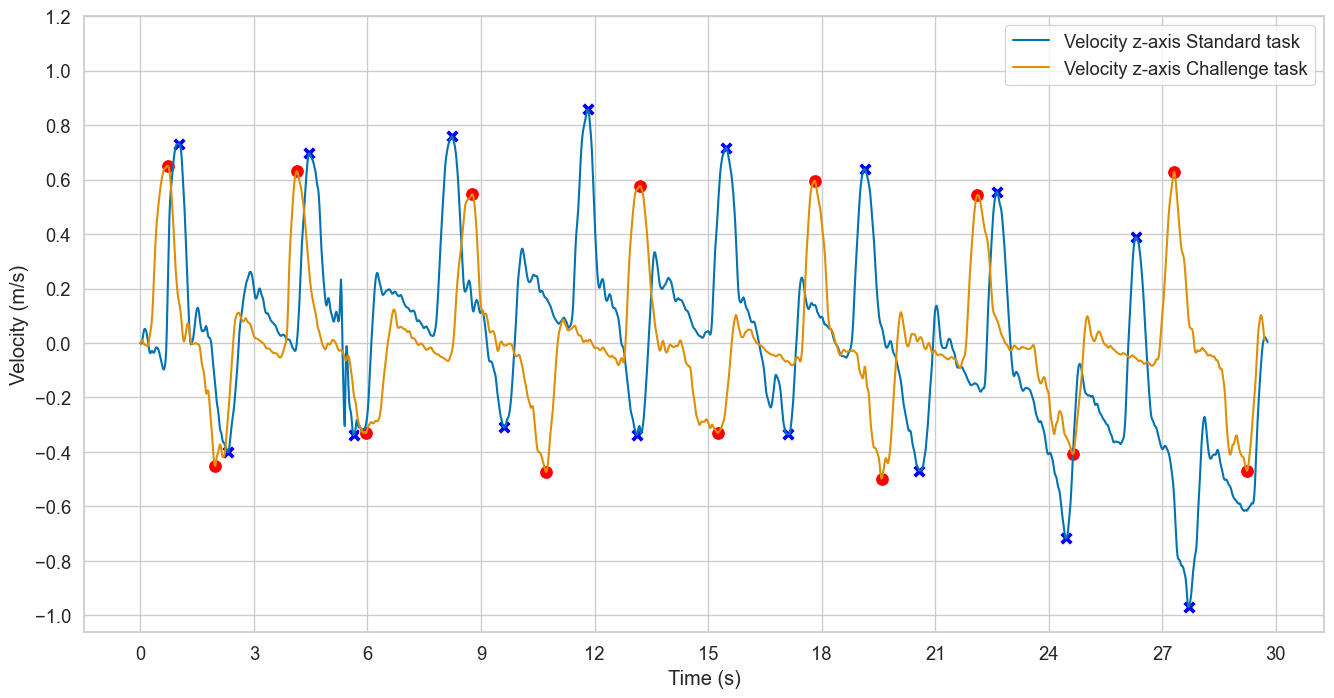

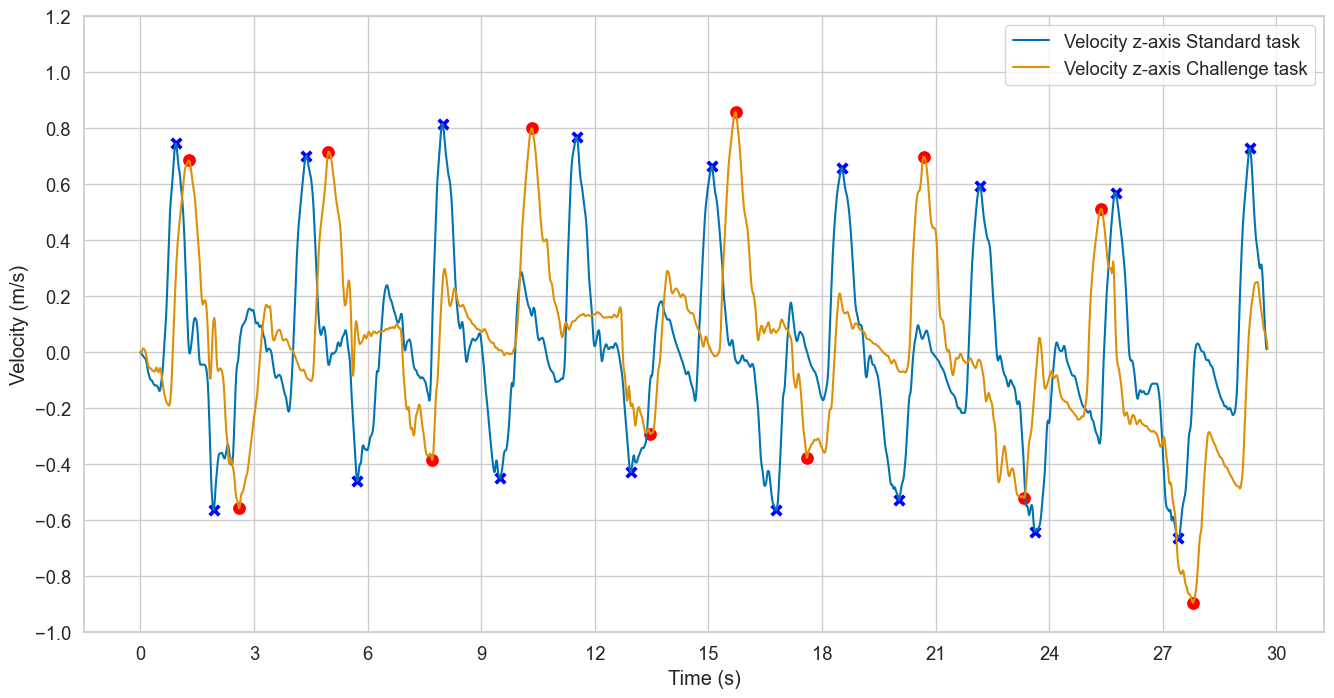

In [371]:
# For each participant in dfs_stand, calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
counts_standard = []
counts_challenge = []

for i in range(len(dfs_stand)):
    import matplotlib.pyplot as plt
    # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y

    dataframe_standard = dfs_stand[i]
    dataframe_challenge = dfs_stand_challenge[i]


    plt.figure(figsize=(16, 8))
    # Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively
    standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(dataframe_standard, 'velocity_z')
    challenge_peaks_z, challenge_troughs_z = calculate_peaks_and_troughs(dataframe_challenge, 'velocity_z')

    count_standard = (len(standard_peaks_z) + len(standard_troughs_z))//2
    count_challenge = (len(challenge_peaks_z) + len(challenge_troughs_z))//2

    counts_standard.append(count_standard)
    counts_challenge.append(count_challenge)

    sns.set_style('whitegrid')
    sns.set_palette('colorblind')

    # Plot velocity lines
    sns.lineplot(x='time_s', y='velocity_z', data=dataframe_standard, label='Velocity z-axis Standard task')
    sns.lineplot(x='time_s', y='velocity_z', data=dataframe_challenge, label='Velocity z-axis Challenge task')

    # Plot peaks and troughs
    sns.scatterplot(x=dataframe_standard['time_s'].iloc[standard_peaks_z],
                    y=dataframe_standard['velocity_z'].iloc[standard_peaks_z],
                    color='blue', marker='X', s=100)

    sns.scatterplot(x=dataframe_standard['time_s'].iloc[standard_troughs_z],
                    y=dataframe_standard['velocity_z'].iloc[standard_troughs_z],
                    color='blue', marker='X', s=100)

    sns.scatterplot(x=dataframe_challenge['time_s'].iloc[challenge_peaks_z],
                    y=dataframe_challenge['velocity_z'].iloc[challenge_peaks_z],
                    color='red', marker='o', s=100)

    sns.scatterplot(x=dataframe_challenge['time_s'].iloc[challenge_troughs_z],
                    y=dataframe_challenge['velocity_z'].iloc[challenge_troughs_z],
                    color='red', marker='o', s=100)
    
    plt.xticks(np.arange(0.0, 30.5, 3))
    plt.yticks(np.arange(-1, 1.3, 0.2))

    debug = False
    if debug:
        # Plot a straight line with x=0 at every trough of standard task
        for trough in standard_troughs_z:
            plt.axvline(x=dataframe_standard['time_s'][trough], color='black', linestyle='--')

        for trough in challenge_troughs_z:
            plt.axvline(x=dataframe_challenge['time_s'][trough], color='green', linestyle='--')
    

    plt.legend()
    # plt.title(f'Peaks and Troughs for participant {i+1}, Standard: {count_standard}, Challenge: {count_challenge}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.show()
    
    




In [401]:
counts_standard = np.array(counts_standard)
counts_challenge = np.array(counts_challenge)

print(counts_standard)
print(counts_challenge)

[ 9 11  9  8  8]
[4 6 7 7 6]


In [400]:
counts_standard
# do shapiro wilk test
stat, p = shapiro(counts_standard)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns


Shapiro-Wilk test: p-value = 0.1458
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


In [404]:
print(counts_challenge)
# do shapiro wilk test
stat, p = shapiro(counts_challenge)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns


[4 6 7 7 6]
Shapiro-Wilk test: p-value = 0.1458
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


In [374]:
counts_challenge

array([4, 6, 7, 7, 6])

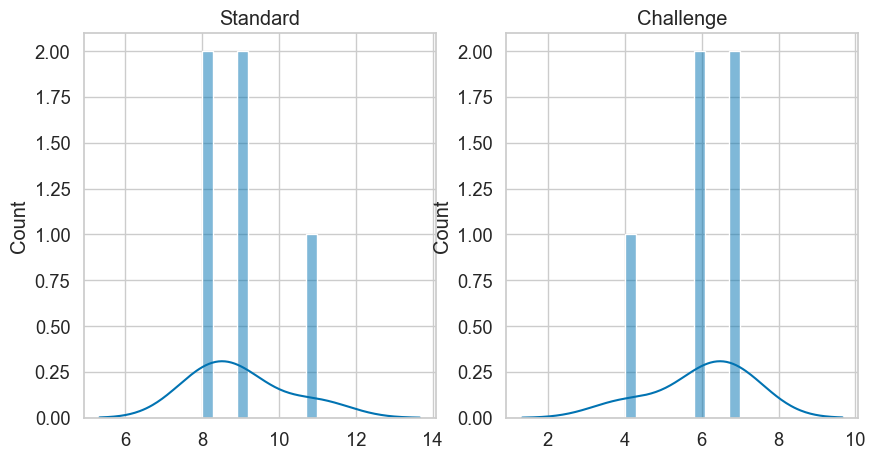

In [375]:
# Plot histogram of counts_standard and counts_challenge with a fit line
# Plot subplots of counts_standard and counts_challenge
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(counts_standard, bins=10, alpha=0.5, label='Standard', ax=axs[0])
sns.histplot(counts_challenge, bins=10, alpha=0.5, label='Challenge', ax=axs[1])
# Add a fit line
sns.kdeplot(counts_standard, label='Standard', ax=axs[0])
sns.kdeplot(counts_challenge, label='Challenge', ax=axs[1])
axs[0].set_title('Standard')
axs[1].set_title('Challenge')
plt.show()


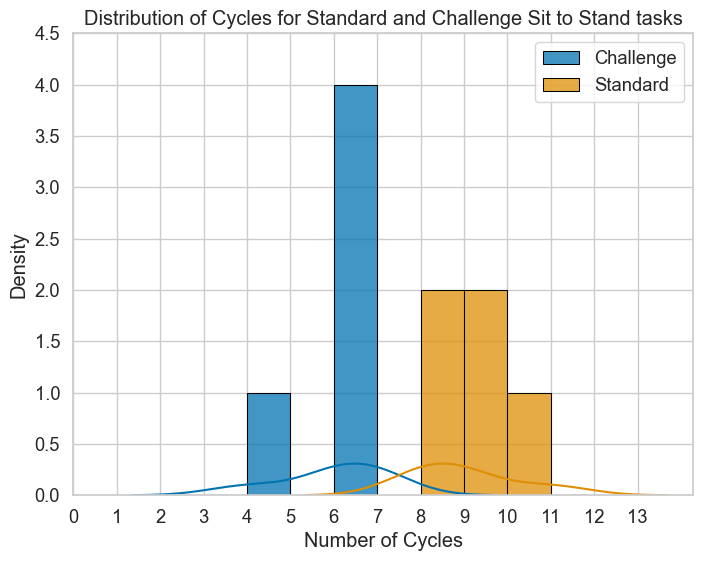

In [376]:
plt.figure(figsize=(8, 6))
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('colorblind')

sns.histplot(counts_challenge, bins=3, label='Challenge', edgecolor='black', linewidth=0.75,)
sns.kdeplot(counts_challenge,)

# add border to the plot
sns.histplot(counts_standard, bins=3, label='Standard', edgecolor='black', linewidth=0.75)
sns.kdeplot(counts_standard)




# Plot a fit line

plt.title('Distribution of Cycles for Standard and Challenge Sit to Stand tasks')
plt.xlabel('Number of Cycles')
plt.xticks(np.arange(0, 14., 1))
plt.yticks(np.arange(0, 5, 0.5))
plt.ylabel('Density')
plt.legend()

plt.show()

Shapiro-Wilk test: p-value = 0.1458
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


<Axes: ylabel='Count'>

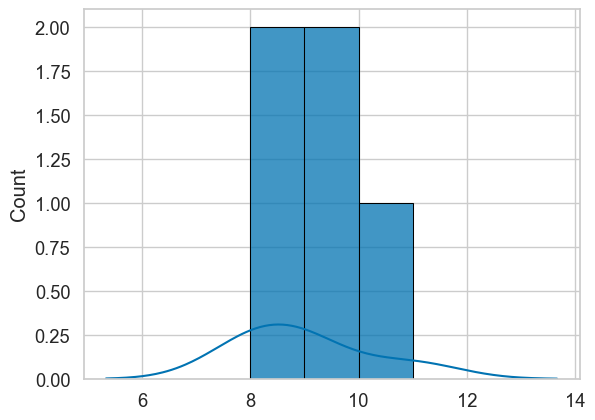

In [402]:
from scipy.stats import shapiro

counts_standard 
stat, p = shapiro(counts_standard)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns


# add border to the plot
sns.histplot(counts_standard, bins=3, label='Standard', edgecolor='black', linewidth=0.75)
sns.kdeplot(counts_standard)

Shapiro-Wilk test: p-value = 0.1458
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


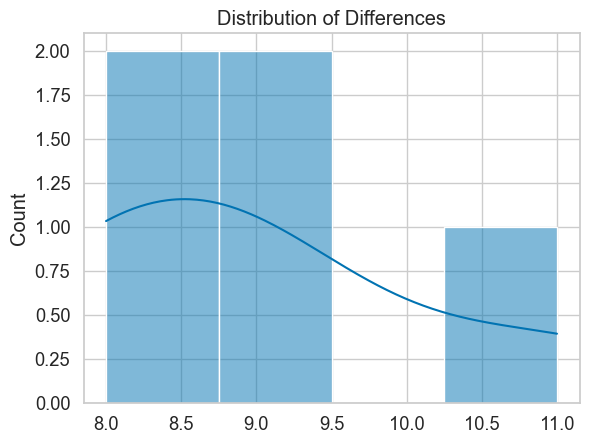

In [398]:
from scipy.stats import shapiro

 
stat, p = shapiro(counts_challenge)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(counts_standard, kde=True)
plt.title("Distribution of Differences")
plt.show()


Shapiro-Wilk test: p-value = 0.1113
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


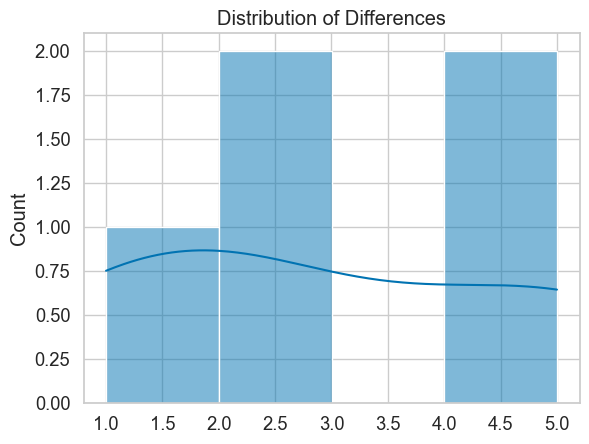

In [379]:
from scipy.stats import shapiro

diff = counts_standard - counts_challenge
stat, p = shapiro(diff)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(diff, kde=True)
plt.title("Distribution of Differences")
plt.show()


In [405]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(counts_standard, counts_challenge)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")

# One sided t-test
# Claim that performance decreases



Paired t-test: t = 3.586, p = 0.0231
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.


In [381]:

df_x = pd.read_csv('/Users/ashish/Desktop/DS4W/sensorhub-analysis/sit_to_stand_imu_xhoel_situp.csv')
df_x


,timestamp_ms,timestamp_μs,freeAcceleration_m/s²_x,freeAcceleration_m/s²_y,freeAcceleration_m/s²_z
0,1747916597173,239962360,0.006865,-0.022782,-0.214370
1,1747916597173,239962360,0.006865,-0.022782,-0.214370
2,1747916597190,239979027,0.005457,-0.019309,-0.227695
3,1747916597190,239979027,0.005457,-0.019309,-0.227695
4,1747916597206,239995694,0.017302,0.020648,-0.237555
...,...,...,...,...,...
417,1747916600640,243429096,0.172247,-0.241084,-0.164057
418,1747916600656,243445763,0.089796,-0.010053,0.051629
419,1747916600656,243445763,0.089796,-0.010053,0.051629
420,1747916600673,243462430,0.070861,0.165751,0.207114


In [382]:
df_single = preprocess_data(df_x)
df_single 
df = df_single



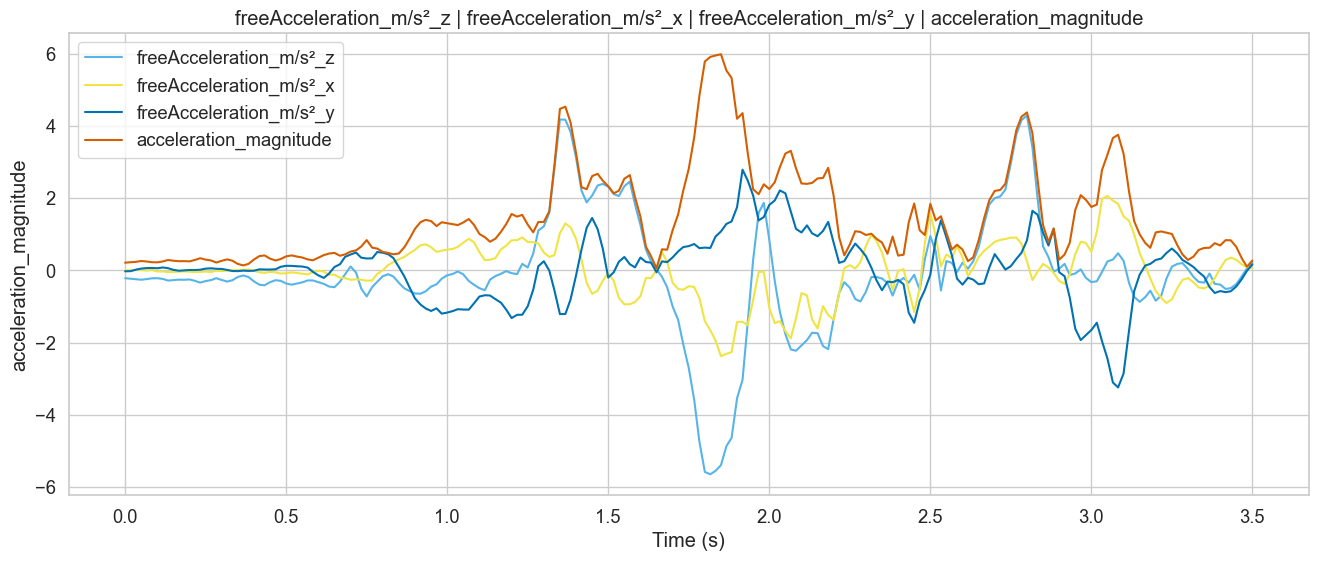

In [383]:
plot_column(df, [
    # 'velocity_z', 
    # 'velocity_magnitude', 
    'freeAcceleration_m/s²_z', 
    'freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 
    'acceleration_magnitude',
    # 'velocity_x', 'velocity_y'
    ])
# Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(df, 'velocity_z')


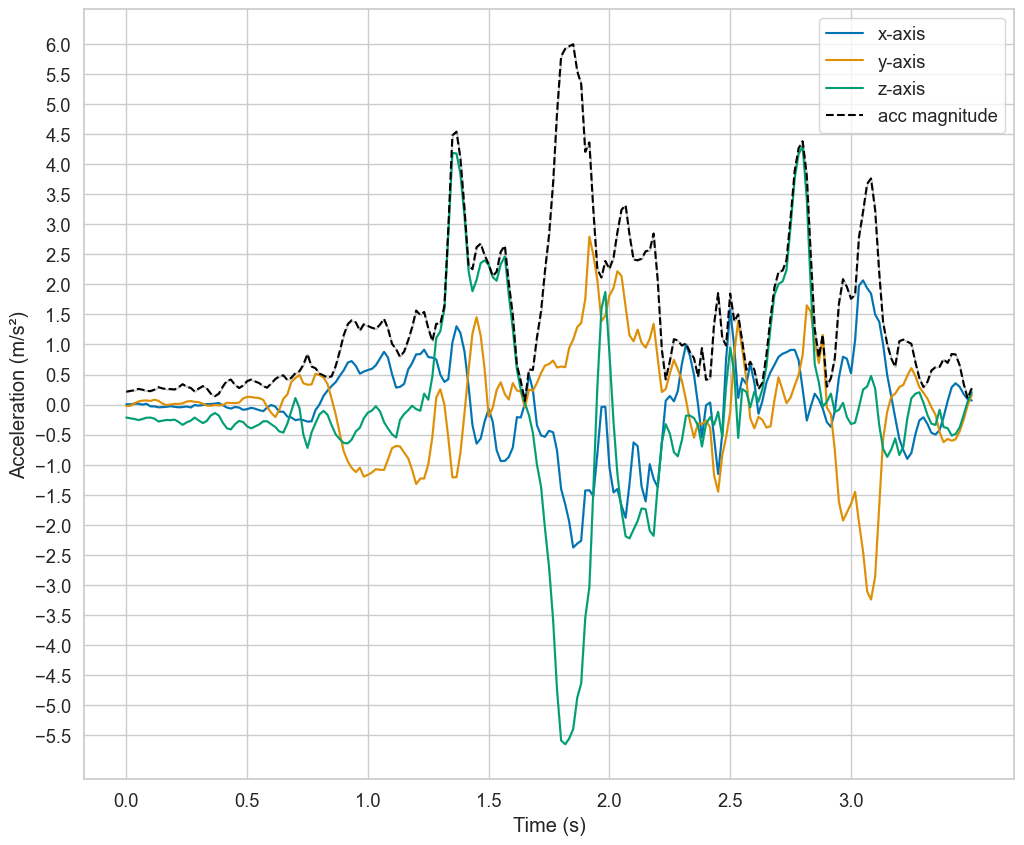

In [384]:
sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(12, 10))
sns.lineplot(data=df_single, x='time_s', y='freeAcceleration_m/s²_x', label='x-axis')
sns.lineplot(data=df_single, x='time_s', y='freeAcceleration_m/s²_y', label='y-axis')
sns.lineplot(data=df_single, x='time_s', y='freeAcceleration_m/s²_z', label='z-axis')
sns.lineplot(data=df_single, x='time_s', y='acceleration_magnitude', label='acc magnitude', linestyle='--', color='black')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.xticks(np.arange(0.0, 3.5, 0.5))
plt.yticks(np.arange(-5.5, 6.5, 0.5))
plt.legend()
plt.show()


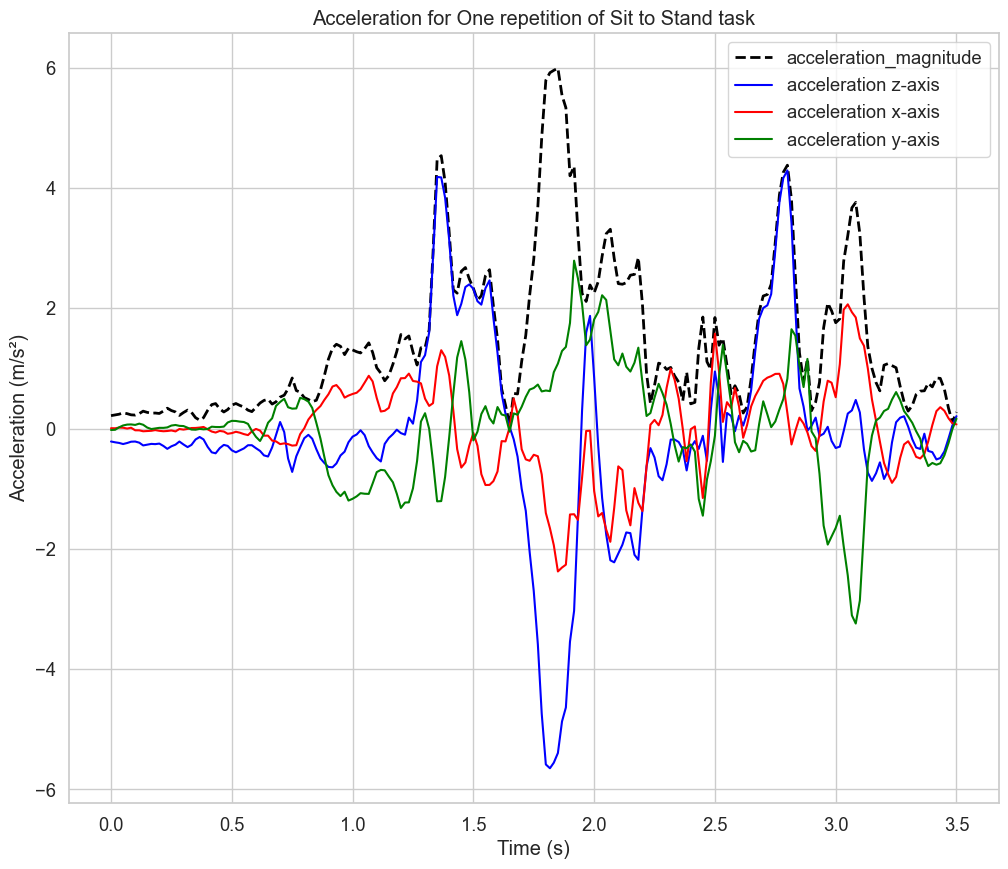

In [385]:
# plot acceleration_magnitude vs time_s
plt.figure(figsize=(12, 10))
plt.plot(df['time_s'], df['acceleration_magnitude'], label='acceleration_magnitude', color='black', linestyle='--', linewidth=2)
plt.plot(df['time_s'], df['freeAcceleration_m/s²_z'], label='acceleration z-axis', color='blue')
plt.plot(df['time_s'], df['freeAcceleration_m/s²_x'], label='acceleration x-axis', color='red')
plt.plot(df['time_s'], df['freeAcceleration_m/s²_y'], label='acceleration y-axis', color='green')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration for One repetition of Sit to Stand task')
plt.legend()
plt.show()


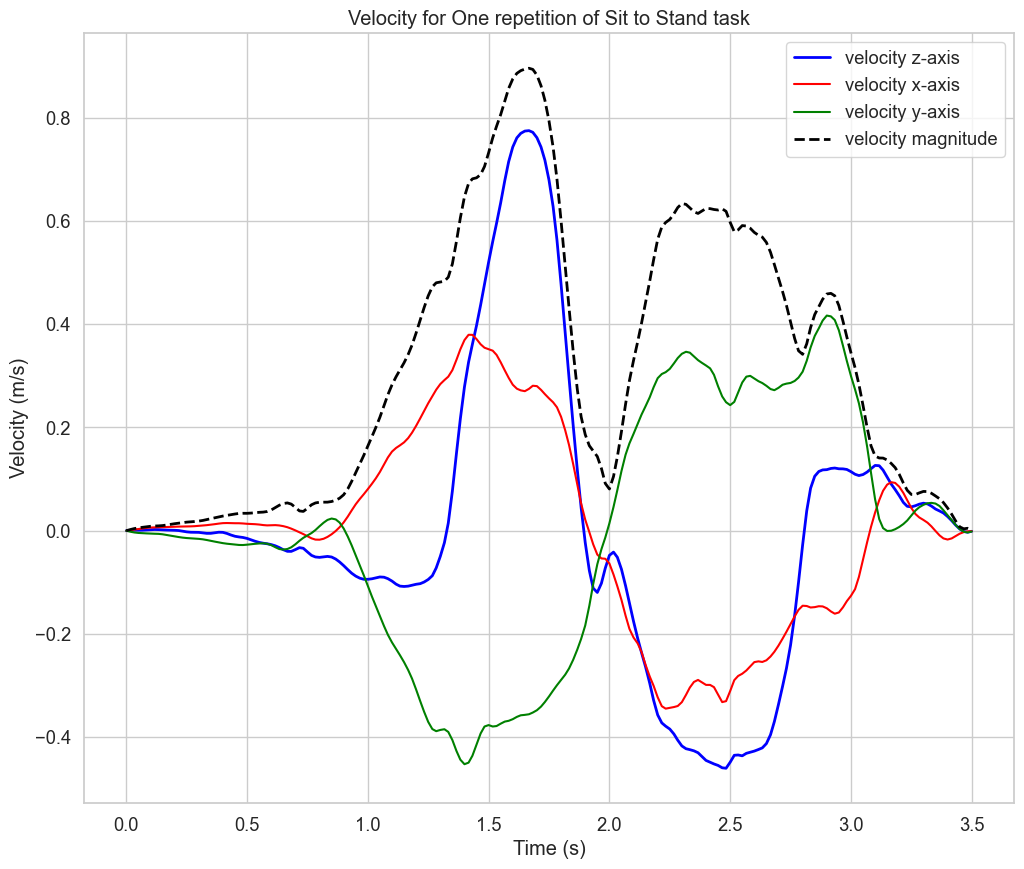

In [386]:
# plot acceleration_magnitude vs time_s
plt.figure(figsize=(12, 10))
plt.plot(df['time_s'], df['velocity_z'], label='velocity z-axis', color='blue', linewidth=2)
plt.plot(df['time_s'], df['velocity_x'], label='velocity x-axis', color='red')
plt.plot(df['time_s'], df['velocity_y'], label='velocity y-axis', color='green')
plt.plot(df['time_s'], df['velocity_magnitude'], label='velocity magnitude', color='black', linestyle='--', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.title('Velocity for One repetition of Sit to Stand task')
plt.show()

# plot acceleration_magnitude vs time_s


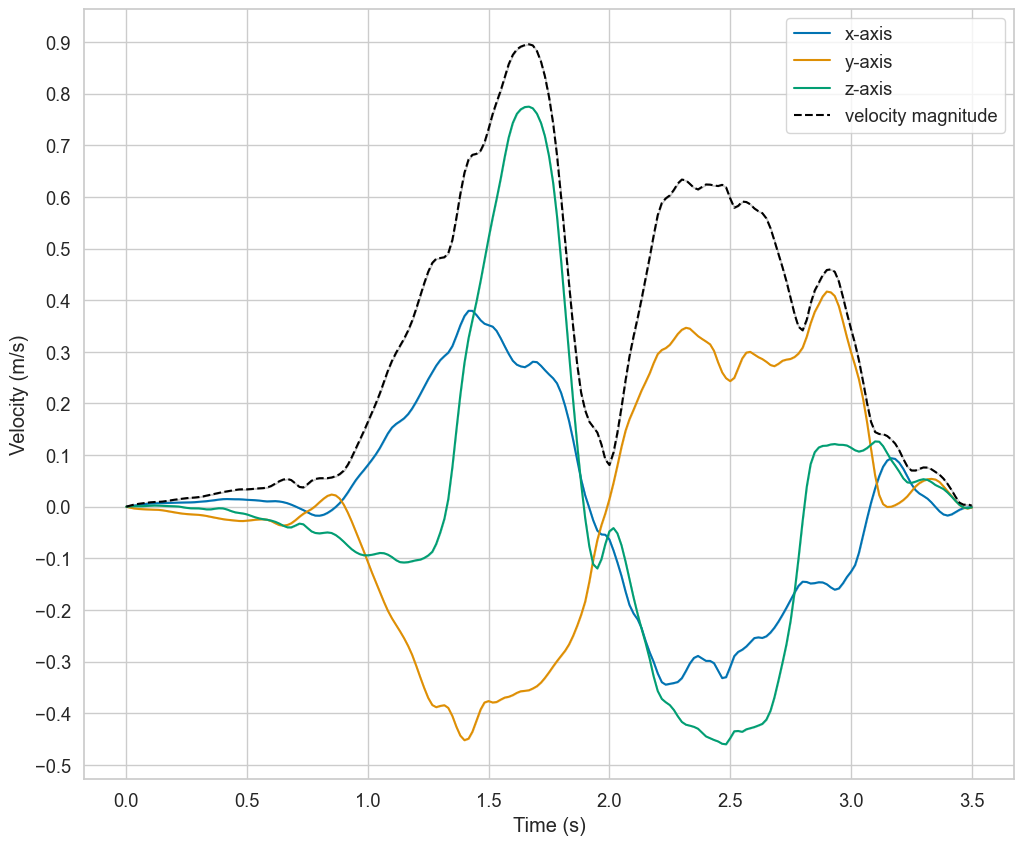

In [387]:
sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(12, 10))
sns.lineplot(data=df_single, x='time_s', y='velocity_x', label='x-axis')
sns.lineplot(data=df_single, x='time_s', y='velocity_y', label='y-axis')
sns.lineplot(data=df_single, x='time_s', y='velocity_z', label='z-axis')
sns.lineplot(data=df_single, x='time_s', y='velocity_magnitude', label='velocity magnitude', linestyle='--', color='black')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.xticks(np.arange(0.0, 3.7, 0.5))
plt.yticks(np.arange(-0.5, 1, 0.1))
plt.legend()
plt.show()


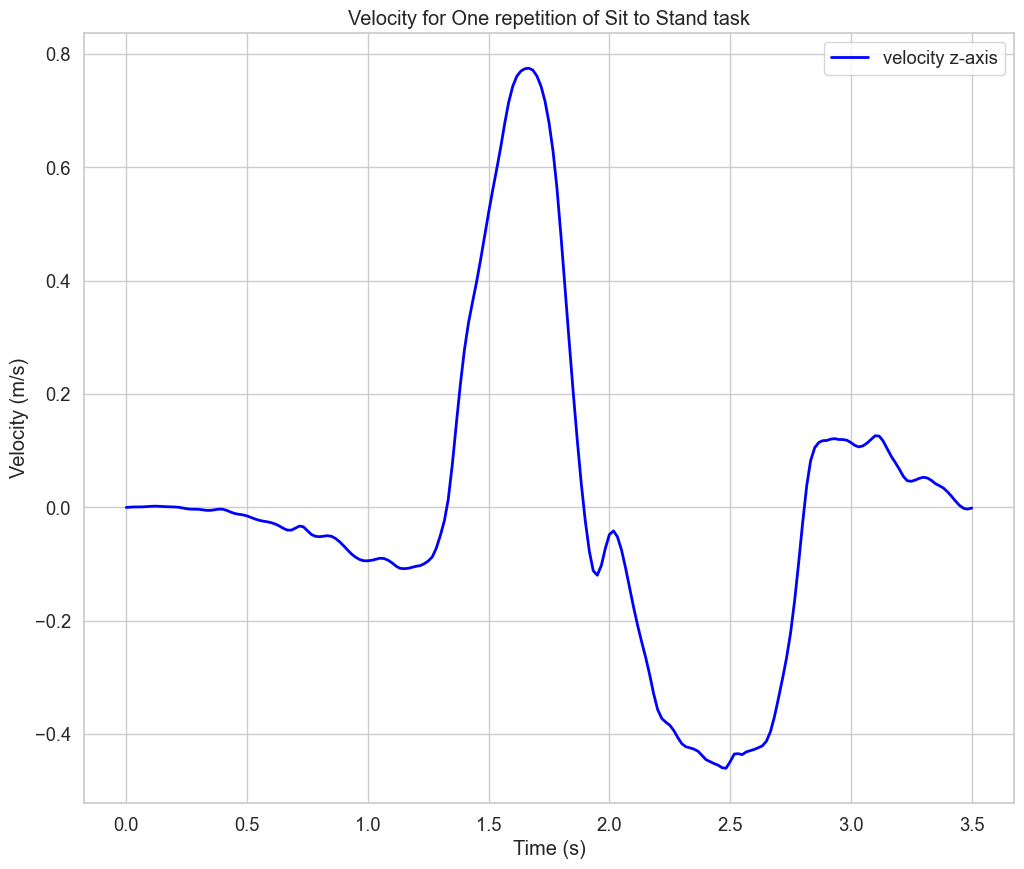

In [388]:
# plot acceleration_magnitude vs time_s
plt.figure(figsize=(12, 10))
plt.plot(df['time_s'], df['velocity_z'], label='velocity z-axis', color='blue', linewidth=2)

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.title('Velocity for One repetition of Sit to Stand task')
plt.show()

# plot acceleration_magnitude vs time_s


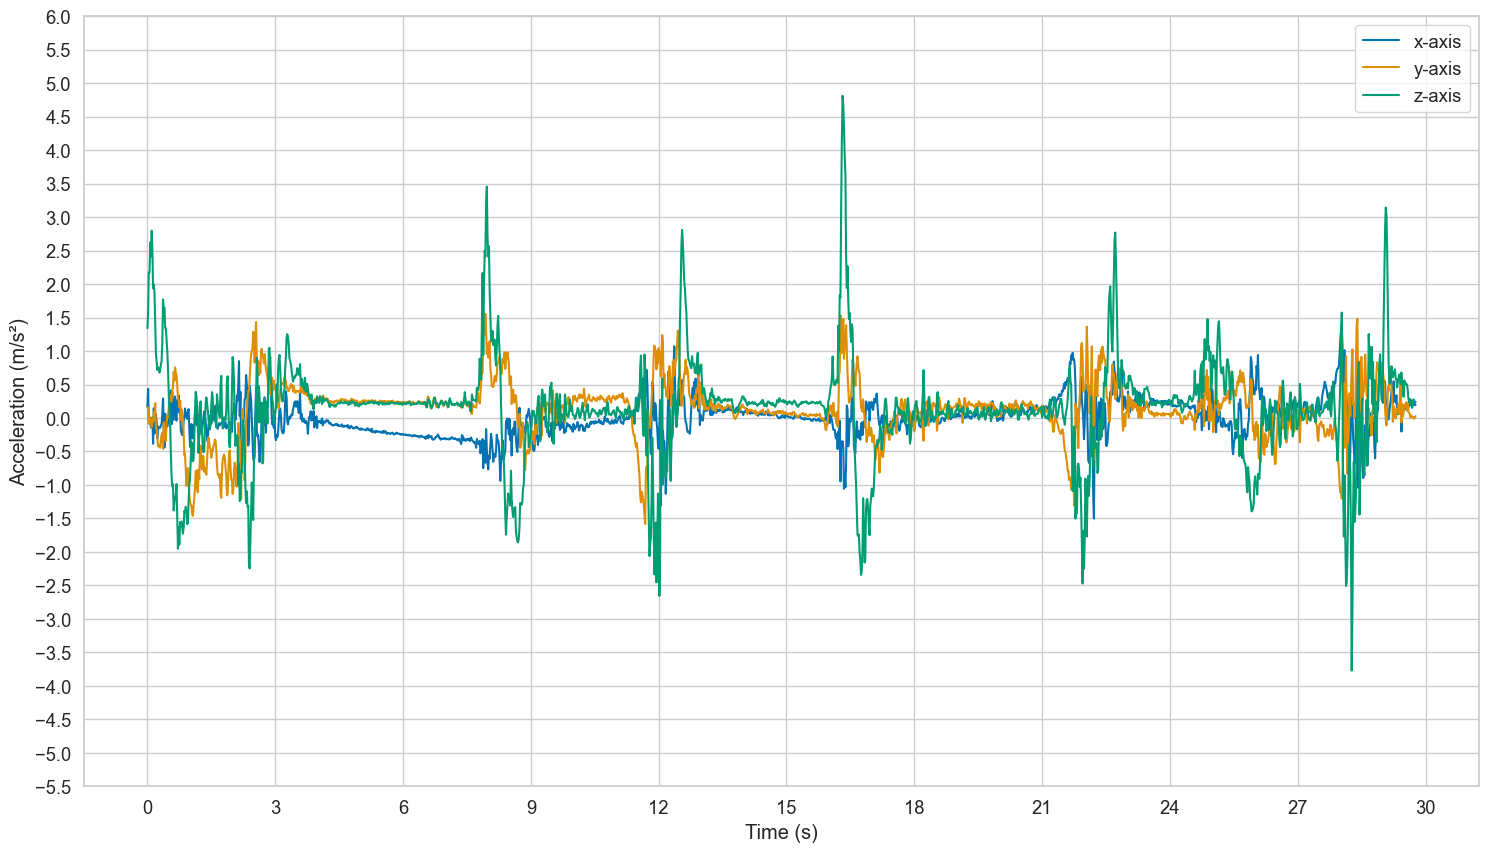

In [389]:
df = dfs_stand_challenge[0]

sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(18, 10))
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_x', label='x-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_y', label='y-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_z', label='z-axis')

plt.xticks(np.arange(0.0, 30.5, 3))
plt.yticks(np.arange(-5.5, 6.5, 0.5))

# # draw a horizontal line at y=0
# plt.axhline(y=0, color='black', linewidth=1)


plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')

# plt.title('Acceleration along x, y and z axis for Standard Sit to Stand task')
# plt.tight_layout()
plt.legend()


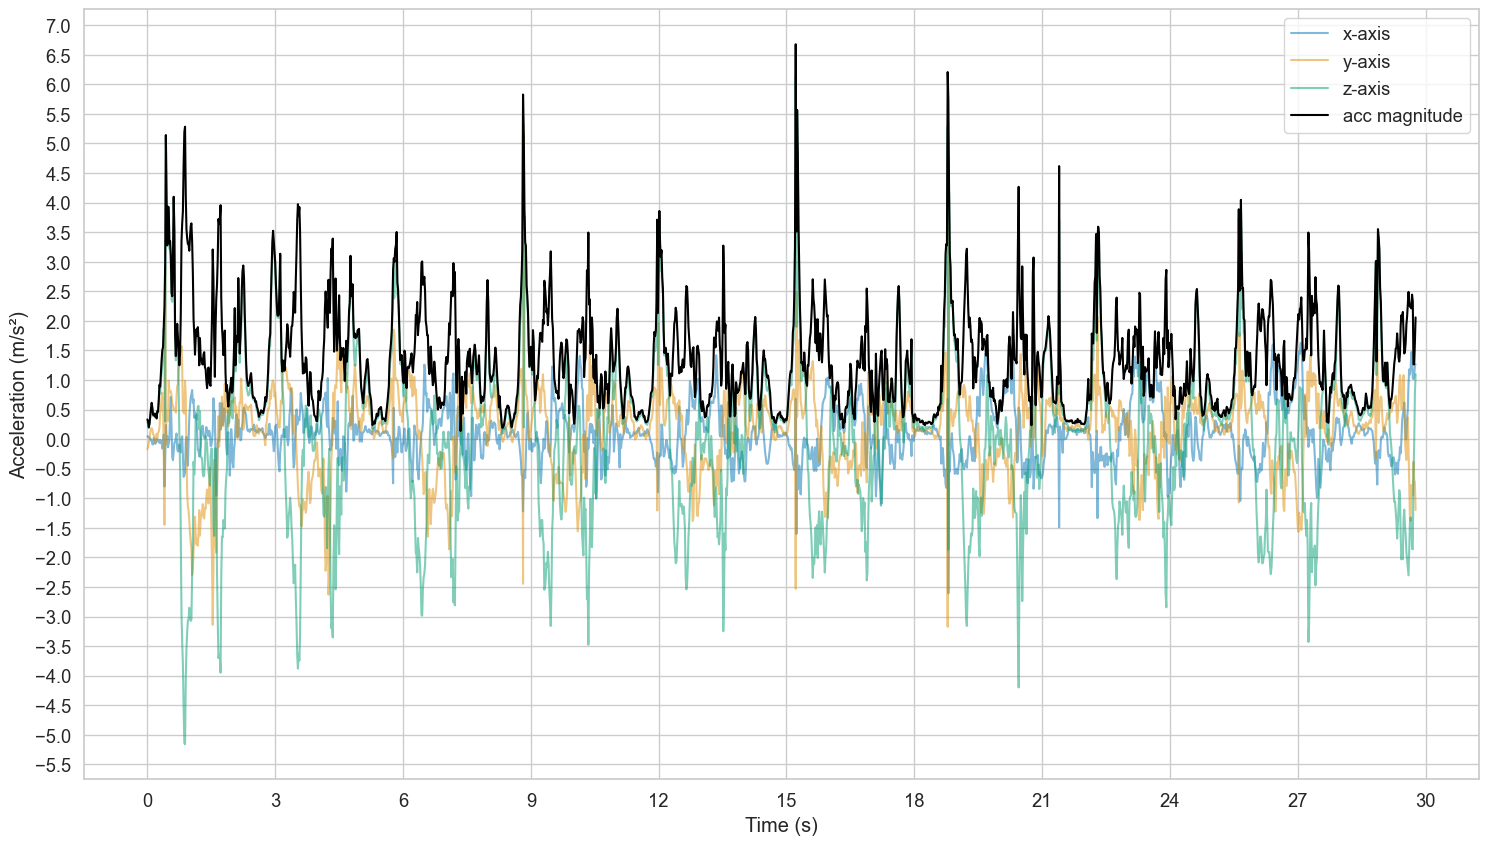

In [390]:
df = dfs_stand[0]

sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(18, 10))
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_x', label='x-axis', alpha=0.5)
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_y', label='y-axis', alpha=0.5)
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_z', label='z-axis', alpha=0.5)
sns.lineplot(data=df, x='time_s', y='acceleration_magnitude', label='acc magnitude', color='black')

plt.xticks(np.arange(0.0, 30.5, 3))
plt.yticks(np.arange(-5.5, 7.5, 0.5))

# # draw a horizontal line at y=0
# plt.axhline(y=0, color='black', linewidth=1)


plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')

# plt.title('Acceleration along x, y and z axis for Standard Sit to Stand task')
# plt.tight_layout()
plt.legend()


Text(0.5, 1.0, 'Acceleration along x, y and z axis for Sit to Stand Challenge task')

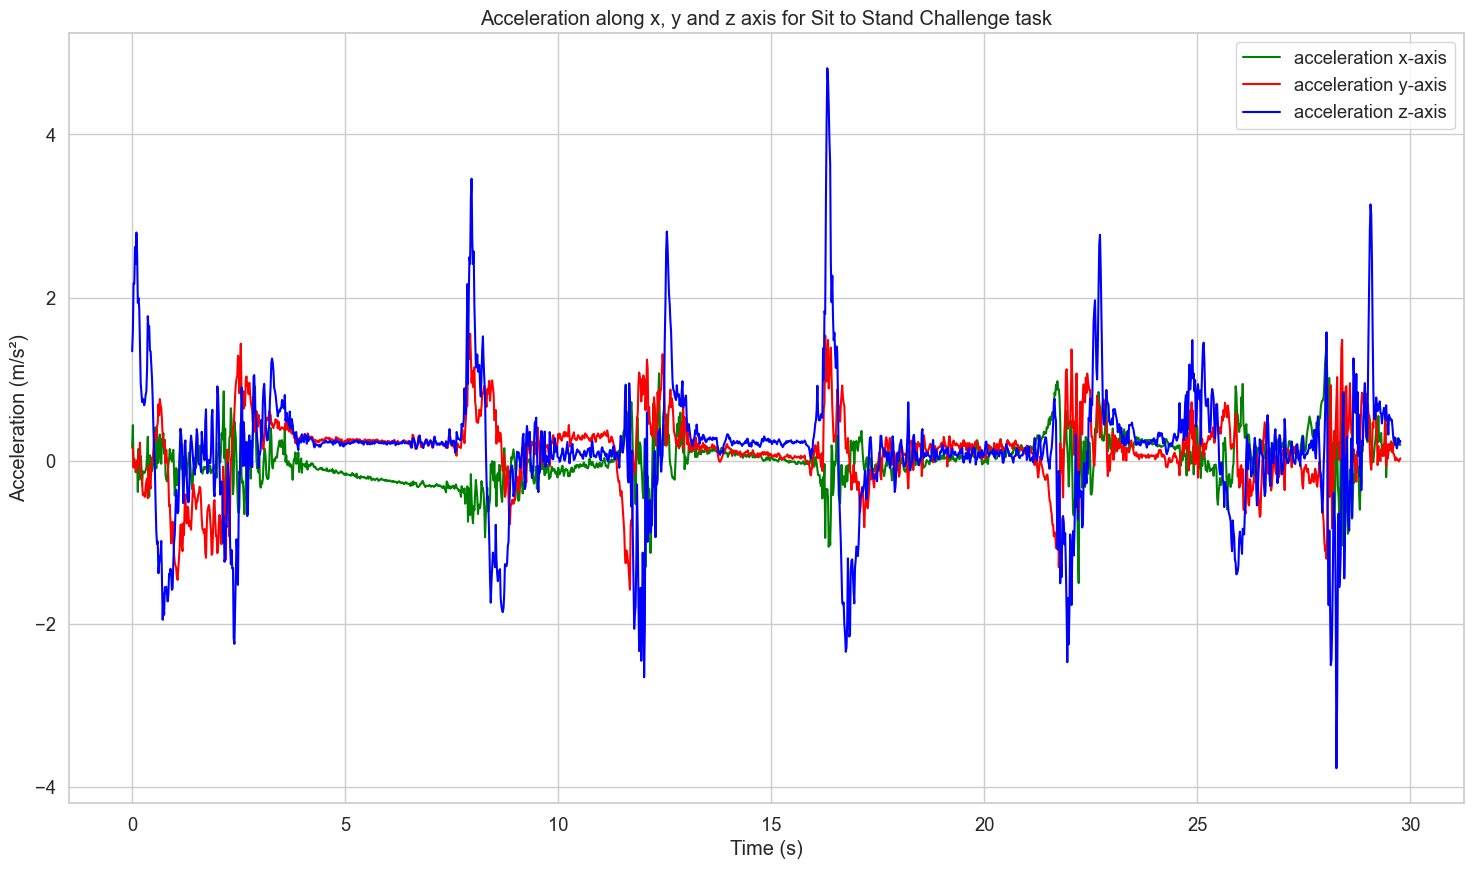

In [391]:
df = dfs_stand_challenge[0]

# plot acceleration along x, y and z axis
plt.figure(figsize=(18, 10))
plt.plot(df['time_s'], df['freeAcceleration_m/s²_x'], label='acceleration x-axis', color='green')
plt.plot(df['time_s'], df['freeAcceleration_m/s²_y'], label='acceleration y-axis', color='red')
plt.plot(df['time_s'], df['freeAcceleration_m/s²_z'], label='acceleration z-axis', color='blue')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration along x, y and z axis for Sit to Stand Challenge task')

In [392]:
def plot_column_sns(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    if title is None:
        title = ' | '.join(column_names)

    sns.set(style="whitegrid", palette="colorblind", font_scale=1.2)

    for i, column_name in enumerate(column_names):
        
        sns.lineplot(
            data=df,
            x='time_s',
            y=column_name,
            linewidth=2.5,
            alpha=0.8
        )
        
        plt.xlabel('Time (s)')
        plt.ylabel('Acceleration Magnitude')
        plt.legend(title='Condition')
        plt.tight_layout()
        plt.show()

    


    # plot the column_name vs time_s
    # plt.figure(figsize=(16, 6))
    # for i, column_name in enumerate(column_names):
    #     plt.plot(df['time_s'], df[column_name], label=column_name, color=colorblind_safe_colors[i])
    #     plt.xlabel('Time (s)')
    #     plt.ylabel(column_name)
    #     plt.legend()
    plt.title(title)

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_33714/1139790886.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Condition')


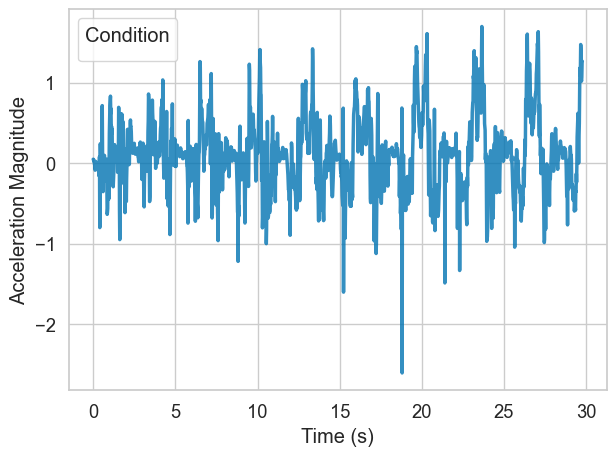

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_33714/1139790886.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Condition')


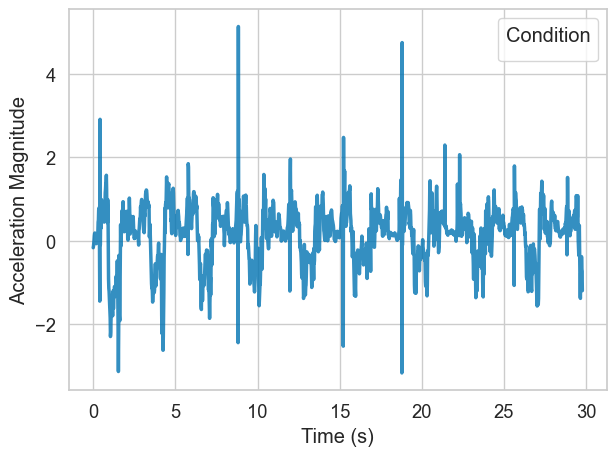

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_33714/1139790886.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Condition')


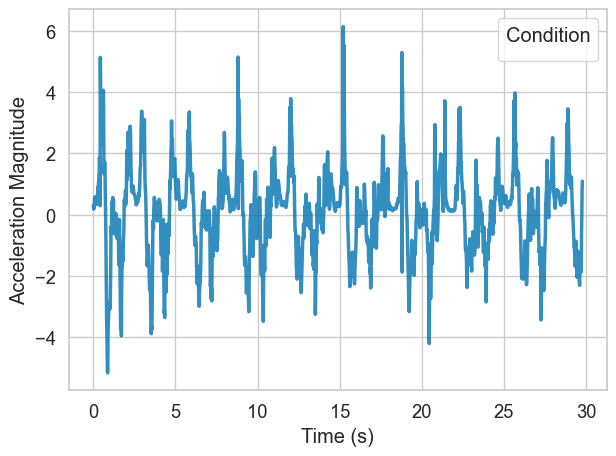

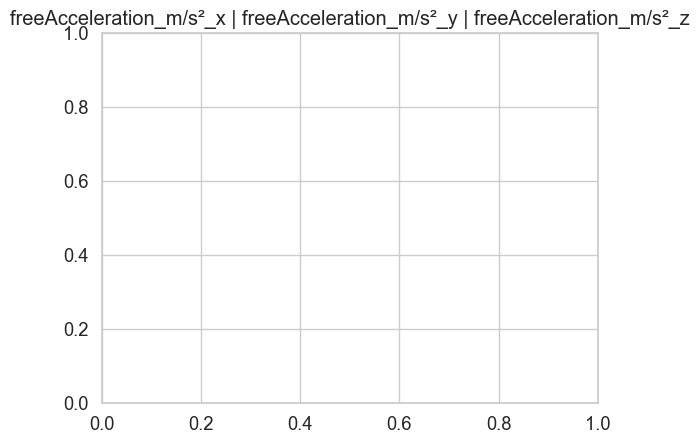

In [393]:
plot_column_sns(dfs_stand[0], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'])

# Aftermath


In [394]:
# Why did we used velocity and not acceleration?